In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joniarroba/noshowappointments")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\joniarroba\noshowappointments\versions\5


In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv(path +"/KaggleV2-May-2016.csv")

# Display first 5 rows only
print("=" * 100)
print("FIRST 5 ROWS OF MEDICAL APPOINTMENT DATASET")
print("=" * 100)
print(df.head().to_string())
print("=" * 100)

FIRST 5 ROWS OF MEDICAL APPOINTMENT DATASET
      PatientId  AppointmentID Gender          ScheduledDay        AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  Diabetes  Alcoholism  Handcap  SMS_received No-show
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1         0           0        0             0      No
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0         0           0        0             0      No
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0         0           0        0             0      No
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0         0           0        0             0      No
4  8.841186e+12        564

In [ ]:

import numpy as np
import pandas as pd

In [ ]:
# check_missing.py
def check_missing_values(df):
    print("=" * 80)
    print("STEP 2: CHECKING MISSING VALUES")
    print("=" * 80)
    
    missing_values = df.isnull().sum()
    total_missing = missing_values.sum()
    
    if total_missing > 0:
        print("  Missing values found:")
        for column, count in missing_values[missing_values > 0].items():
            percentage = (count / len(df)) * 100
            print(f"  - {column}: {count:,} ({percentage:.2f}%)")
    else:
        print(" No missing values found!")
    
    return df


df = check_missing_values(df)

STEP 2: CHECKING MISSING VALUES
 No missing values found!


In [17]:
# check_duplicates.py
def check_and_remove_duplicates(df):
    print("\n" + "=" * 80)
    print("STEP 3: CHECKING DUPLICATES")
    print("=" * 80)
    
    duplicate_rows = df.duplicated().sum()
    
    if duplicate_rows > 0:
        print(f" Found {duplicate_rows:,} duplicate rows")
        print("Removing duplicate rows...")
        df_clean = df.drop_duplicates()
        print(f"Rows after removal: {len(df_clean):,}")
        return df_clean
    else:
        print(" No duplicate rows found!")
        return df

# Run
df = check_and_remove_duplicates(df)


STEP 3: CHECKING DUPLICATES
 No duplicate rows found!


In [18]:
# validate_ages.py
def validate_ages(df):
    print("\n" + "=" * 80)
    print("STEP 4: VALIDATING AGES")
    print("=" * 80)
    
    invalid_ages = (df['Age'] < 0).sum()
    
    if invalid_ages > 0:
        print(f"  Found {invalid_ages:,} invalid ages (Age < 0)")
        print(" Removing records with invalid ages...")
        original_count = len(df)
        df_clean = df[df['Age'] >= 0]
        removed_count = original_count - len(df_clean)
        print(f" Removed {removed_count:,} records")
        print(f" Remaining rows: {len(df_clean):,}")
        return df_clean
    else:
        print(" All ages are valid (≥ 0)")
        return df

# Run
df = validate_ages(df)


STEP 4: VALIDATING AGES
 All ages are valid (≥ 0)


In [20]:
# File: fix_dates_and_continue.py
print("=" * 80)
print("FIRST: CONVERTING DATES TO DATETIME FORMAT")
print("=" * 80)

# Check current data types
print(" Current data types of date columns:")
print(f"   • ScheduledDay type: {df['ScheduledDay'].dtype}")
print(f"   • AppointmentDay type: {df['AppointmentDay'].dtype}")

# Convert to datetime
print("\n Converting to datetime...")
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

print(" Date conversion complete!")
print(f"   • ScheduledDay type: {df['ScheduledDay'].dtype}")
print(f"   • AppointmentDay type: {df['AppointmentDay'].dtype}")

# Show sample
print("\n Sample of converted dates:")
sample_df = df[['ScheduledDay', 'AppointmentDay']].head(3).copy()
sample_df['ScheduledDay_formatted'] = sample_df['ScheduledDay'].dt.strftime('%Y-%m-%d %H:%M:%S')
sample_df['AppointmentDay_formatted'] = sample_df['AppointmentDay'].dt.strftime('%Y-%m-%d %H:%M:%S')
print(sample_df[['ScheduledDay_formatted', 'AppointmentDay_formatted']].to_string())


FIRST: CONVERTING DATES TO DATETIME FORMAT
 Current data types of date columns:
   • ScheduledDay type: datetime64[ns, UTC]
   • AppointmentDay type: datetime64[ns, UTC]

 Converting to datetime...
 Date conversion complete!
   • ScheduledDay type: datetime64[ns, UTC]
   • AppointmentDay type: datetime64[ns, UTC]

 Sample of converted dates:
  ScheduledDay_formatted AppointmentDay_formatted
0    2016-04-29 18:38:08      2016-04-29 00:00:00
1    2016-04-29 16:08:27      2016-04-29 00:00:00
2    2016-04-29 16:19:04      2016-04-29 00:00:00


In [21]:
# File: feature_step1_waiting_days_fixed.py
def create_waiting_days(df):
    print("=" * 80)
    print("FEATURE 1: CALCULATING WAITING DAYS")
    print("=" * 80)
    
    # Make sure dates are in datetime format
    if df['ScheduledDay'].dtype != 'datetime64[ns]':
        print(" Converting ScheduledDay to datetime...")
        df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
    
    if df['AppointmentDay'].dtype != 'datetime64[ns]':
        print(" Converting AppointmentDay to datetime...")
        df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
    
    df_modified = df.copy()
    
    # Calculate days between scheduling and appointment
    df_modified['AwaitingDays'] = (df_modified['AppointmentDay'] - df_modified['ScheduledDay']).dt.days
    
    # Check for any negative values
    negative_count = (df_modified['AwaitingDays'] < 0).sum()
    if negative_count > 0:
        print(f"  Found {negative_count} negative waiting days")
        df_modified['AwaitingDays'] = df_modified['AwaitingDays'].clip(lower=0)
        print(" Set negative values to 0")
    
    # Print statistics
    print(f" Created 'AwaitingDays' feature")
    print(f"   • Min: {df_modified['AwaitingDays'].min()} days")
    print(f"   • Max: {df_modified['AwaitingDays'].max()} days")
    print(f"   • Mean: {df_modified['AwaitingDays'].mean():.1f} days")
    print(f"   • Median: {df_modified['AwaitingDays'].median():.1f} days")
    
    # Show distribution
    print(f"\n Waiting Days Distribution:")
    bins = [0, 1, 3, 7, 14, 30, 1000]
    labels = ['Same day', '1-3 days', '4-7 days', '8-14 days', '15-30 days', '30+ days']
    
    for i in range(len(bins)-1):
        lower = bins[i]
        upper = bins[i+1] if i < len(bins)-2 else 1000
        count = ((df_modified['AwaitingDays'] >= lower) & (df_modified['AwaitingDays'] < upper)).sum()
        percentage = (count / len(df_modified)) * 100
        print(f"   • {labels[i]}: {count:,} appointments ({percentage:.1f}%)")
    
    return df_modified

df = create_waiting_days(df)

FEATURE 1: CALCULATING WAITING DAYS
 Converting ScheduledDay to datetime...
 Converting AppointmentDay to datetime...
  Found 38567 negative waiting days
 Set negative values to 0
 Created 'AwaitingDays' feature
   • Min: 0 days
   • Max: 178 days
   • Mean: 9.5 days
   • Median: 3.0 days

 Waiting Days Distribution:
   • Same day: 43,780 appointments (39.6%)
   • 1-3 days: 9,462 appointments (8.6%)
   • 4-7 days: 17,510 appointments (15.8%)
   • 8-14 days: 12,025 appointments (10.9%)
   • 15-30 days: 17,371 appointments (15.7%)
   • 30+ days: 10,378 appointments (9.4%)


In [22]:
# File: feature_step3_age_groups.py
def create_age_groups(df):
    print("\n" + "=" * 80)
    print("FEATURE 3: AGE GROUPS")
    print("=" * 80)
    
    df_modified = df.copy()
    
    # Define age bins and labels
    bins = [0, 12, 19, 35, 60, 100]
    labels = ['Child (0-12)', 'Teen (13-19)', 'Young Adult (20-35)', 
              'Adult (36-60)', 'Senior (60+)']
    
    df_modified['AgeGroup'] = pd.cut(df_modified['Age'], bins=bins, labels=labels)
    
    print(f" Created 'AgeGroup' feature with {len(labels)} categories")
    
    print(f"\n Age Group Distribution:")
    for i, group in enumerate(labels):
        count = (df_modified['AgeGroup'] == group).sum()
        percentage = (count / len(df_modified)) * 100
        
        # Get age range
        lower = bins[i]
        upper = bins[i+1] if i < len(bins)-1 else 100
        
        print(f"   • {group}: {count:,} patients ({percentage:.1f}%)")
        print(f"     Age range: {lower}-{upper} years")
    
    # Also create binary age flags
    df_modified['IsChild'] = (df_modified['Age'] < 18).astype(int)
    df_modified['IsSenior'] = (df_modified['Age'] >= 60).astype(int)
    
    child_count = df_modified['IsChild'].sum()
    senior_count = df_modified['IsSenior'].sum()
    
    print(f"\n Additional age flags:")
    print(f"   • 'IsChild': {child_count:,} children (<18)")
    print(f"   • 'IsSenior': {senior_count:,} seniors (60+)")
    
    return df_modified

# Run
df = create_age_groups(df)


FEATURE 3: AGE GROUPS
 Created 'AgeGroup' feature with 5 categories

 Age Group Distribution:
   • Child (0-12): 17,497 patients (15.8%)
     Age range: 0-12 years
   • Teen (13-19): 9,375 patients (8.5%)
     Age range: 12-19 years
   • Young Adult (20-35): 22,592 patients (20.4%)
     Age range: 19-35 years
   • Adult (36-60): 37,761 patients (34.2%)
     Age range: 35-60 years
   • Senior (60+): 19,755 patients (17.9%)
     Age range: 60-100 years

 Additional age flags:
   • 'IsChild': 27,379 children (<18)
   • 'IsSenior': 21,173 seniors (60+)


In [23]:
# File: feature_step4_health_features.py
def create_health_features(df):
    print("\n" + "=" * 80)
    print("FEATURE 4: HEALTH CONDITION FEATURES")
    print("=" * 80)
    
    df_modified = df.copy()
    
    print(" Creating health-related features...")
    
    # 1. Total number of conditions
    df_modified['TotalConditions'] = (
        df_modified['Hipertension'] + 
        df_modified['Diabetes'] + 
        df_modified['Alcoholism'] + 
        (df_modified['Handcap'] > 0).astype(int)
    )
    print(f"    'TotalConditions': Sum of all health issues")
    
    # 2. Has any chronic condition
    df_modified['HasChronicCondition'] = (df_modified['TotalConditions'] > 0).astype(int)
    chronic_count = df_modified['HasChronicCondition'].sum()
    chronic_percentage = (chronic_count / len(df_modified)) * 100
    print(f"    'HasChronicCondition': {chronic_count:,} patients ({chronic_percentage:.1f}%)")
    
    # 3. Has multiple conditions
    df_modified['HasMultipleConditions'] = (df_modified['TotalConditions'] > 1).astype(int)
    multi_count = df_modified['HasMultipleConditions'].sum()
    multi_percentage = (multi_count / len(df_modified)) * 100
    print(f"    'HasMultipleConditions': {multi_count:,} patients ({multi_percentage:.1f}%)")
    
    # Show condition breakdown
    print(f"\n Individual Condition Prevalence:")
    conditions = {
        'Hipertension': 'Hypertension',
        'Diabetes': 'Diabetes', 
        'Alcoholism': 'Alcoholism',
        'Handcap': 'Handicap (any level)'
    }
    
    for col, name in conditions.items():
        if col == 'Handcap':
            count = (df_modified[col] > 0).sum()
        else:
            count = df_modified[col].sum()
        percentage = (count / len(df_modified)) * 100
        print(f"   • {name}: {count:,} patients ({percentage:.1f}%)")
    
    print(f"\n Total Conditions Distribution:")
    max_conditions = df_modified['TotalConditions'].max()
    for i in range(0, max_conditions + 1):
        count = (df_modified['TotalConditions'] == i).sum()
        percentage = (count / len(df_modified)) * 100
        print(f"   • {i} conditions: {count:,} patients ({percentage:.1f}%)")
    
    return df_modified

# Run
df = create_health_features(df)


FEATURE 4: HEALTH CONDITION FEATURES
 Creating health-related features...
    'TotalConditions': Sum of all health issues
    'HasChronicCondition': 26,412 patients (23.9%)
    'HasMultipleConditions': 8,289 patients (7.5%)

 Individual Condition Prevalence:
   • Hypertension: 21,801 patients (19.7%)
   • Diabetes: 7,943 patients (7.2%)
   • Alcoholism: 3,360 patients (3.0%)
   • Handicap (any level): 2,241 patients (2.0%)

 Total Conditions Distribution:
   • 0 conditions: 84,114 patients (76.1%)
   • 1 conditions: 18,123 patients (16.4%)
   • 2 conditions: 7,658 patients (6.9%)
   • 3 conditions: 618 patients (0.6%)
   • 4 conditions: 13 patients (0.0%)


In [24]:
# File: feature_step5_target_encoding.py
def create_target_encoding(df):
    print("\n" + "=" * 80)
    print("FEATURE 5: TARGET VARIABLE ENCODING")
    print("=" * 80)
    
    df_modified = df.copy()
    
    # Create binary target variable
    df_modified['NoShow_binary'] = df_modified['No-show'].map({'Yes': 1, 'No': 0})
    
    print(f" Created 'NoShow_binary' feature")
    print(f"   • 0 = Show up to appointment")
    print(f"   • 1 = No-show (missed appointment)")
    
    # Show distribution
    show_count = (df_modified['NoShow_binary'] == 0).sum()
    noshow_count = (df_modified['NoShow_binary'] == 1).sum()
    total_count = len(df_modified)
    
    show_percentage = (show_count / total_count) * 100
    noshow_percentage = (noshow_count / total_count) * 100
    
    print(f"\n Target Variable Distribution:")
    print(f"   • Show (0): {show_count:,} appointments ({show_percentage:.1f}%)")
    print(f"   • No-show (1): {noshow_count:,} appointments ({noshow_percentage:.1f}%)")
    
    # Check if balanced
    if 0.4 <= noshow_percentage/100 <= 0.6:
        print("    Dataset is balanced")
    else:
        print(f"     Dataset is imbalanced (no-show rate: {noshow_percentage:.1f}%)")
    
    return df_modified

# Run
df = create_target_encoding(df)


FEATURE 5: TARGET VARIABLE ENCODING
 Created 'NoShow_binary' feature
   • 0 = Show up to appointment
   • 1 = No-show (missed appointment)

 Target Variable Distribution:
   • Show (0): 88,207 appointments (79.8%)
   • No-show (1): 22,319 appointments (20.2%)
     Dataset is imbalanced (no-show rate: 20.2%)


In [25]:
# File: feature_step6_waiting_categories.py
def create_waiting_categories(df):
    print("\n" + "=" * 80)
    print("FEATURE 6: WAITING PERIOD CATEGORIES")
    print("=" * 80)
    
    df_modified = df.copy()
    
    # Create waiting period categories
    def categorize_waiting(days):
        if days == 0:
            return 'Same day'
        elif 1 <= days <= 3:
            return 'Short (1-3 days)'
        elif 4 <= days <= 7:
            return 'Medium (4-7 days)'
        elif 8 <= days <= 14:
            return 'Long (8-14 days)'
        else:
            return 'Very long (15+ days)'
    
    df_modified['WaitingCategory'] = df_modified['AwaitingDays'].apply(categorize_waiting)
    
    print(f" Created 'WaitingCategory' feature")
    
    # Show distribution
    print(f"\n Waiting Category Distribution:")
    categories = ['Same day', 'Short (1-3 days)', 'Medium (4-7 days)', 
                  'Long (8-14 days)', 'Very long (15+ days)']
    
    for category in categories:
        count = (df_modified['WaitingCategory'] == category).sum()
        percentage = (count / len(df_modified)) * 100
        print(f"   • {category}: {count:,} appointments ({percentage:.1f}%)")
    
    # Calculate no-show rates by waiting category
    print(f"\n No-show Rates by Waiting Category:")
    for category in categories:
        category_data = df_modified[df_modified['WaitingCategory'] == category]
        if len(category_data) > 0:
            noshow_rate = category_data['NoShow_binary'].mean() * 100
            count = len(category_data)
            print(f"   • {category}: {noshow_rate:.1f}% no-show rate ({count:,} appointments)")
    
    return df_modified

# Run
df = create_waiting_categories(df)


FEATURE 6: WAITING PERIOD CATEGORIES
 Created 'WaitingCategory' feature

 Waiting Category Distribution:
   • Same day: 43,780 appointments (39.6%)
   • Short (1-3 days): 14,752 appointments (13.3%)
   • Medium (4-7 days): 14,552 appointments (13.2%)
   • Long (8-14 days): 11,196 appointments (10.1%)
   • Very long (15+ days): 26,246 appointments (23.7%)

 No-show Rates by Waiting Category:
   • Same day: 6.6% no-show rate (43,780 appointments)
   • Short (1-3 days): 23.6% no-show rate (14,752 appointments)
   • Medium (4-7 days): 26.5% no-show rate (14,552 appointments)
   • Long (8-14 days): 31.2% no-show rate (11,196 appointments)
   • Very long (15+ days): 32.7% no-show rate (26,246 appointments)


In [27]:
# File: feature_step7_final_summary.py
def final_feature_summary(df):
    print("\n" + "=" * 80)
    print("FEATURE ENGINEERING - FINAL SUMMARY")
    print("=" * 80)
    
    # Original columns from the Kaggle dataset
    original_columns = [
        'PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 
        'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 
        'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 
        'SMS_received', 'No-show'
    ]
    
    # Get new engineered features
    new_features = [col for col in df.columns if col not in original_columns]
    
    print(f" DATASET GROWTH:")
    print(f"   • Original columns: {len(original_columns)}")
    print(f"   • New features created: {len(new_features)}")
    print(f"   • Total columns now: {len(df.columns)}")
    
    print(f"\n NEW FEATURES CREATED (15 total):")
    
    # Feature descriptions
    feature_info = {
        'AwaitingDays': {'desc': 'Days between scheduling and appointment', 'type': 'numerical'},
        'ScheduledHour': {'desc': 'Hour when appointment was scheduled (0-23)', 'type': 'numerical'},
        'AppointmentDayOfWeek': {'desc': 'Day of week for appointment', 'type': 'categorical'},
        'AppointmentMonth': {'desc': 'Month of appointment (1-12)', 'type': 'numerical'},
        'IsWeekend': {'desc': 'Weekend flag (1=Sat/Sun, 0=Weekday)', 'type': 'binary'},
        'TimeOfDay': {'desc': 'Time category (Morning/Afternoon/Evening/Night)', 'type': 'categorical'},
        'AgeGroup': {'desc': 'Categorical age groups', 'type': 'categorical'},
        'IsChild': {'desc': 'Child flag (<18 years)', 'type': 'binary'},
        'IsSenior': {'desc': 'Senior flag (≥60 years)', 'type': 'binary'},
        'TotalConditions': {'desc': 'Sum of all health conditions', 'type': 'numerical'},
        'HasChronicCondition': {'desc': 'Has at least one chronic condition', 'type': 'binary'},
        'HasMultipleConditions': {'desc': 'Has multiple chronic conditions', 'type': 'binary'},
        'NoShow_binary': {'desc': 'Binary target (1=No-show, 0=Show)', 'type': 'binary'},
        'WaitingCategory': {'desc': 'Categorized waiting periods', 'type': 'categorical'}
    }
    
    print(f"{'No.':<3} {'Feature':<25} {'Type':<15} {'Unique':<8} {'Description':<40}")
    print("-" * 95)
    
    for i, feature in enumerate(new_features, 1):
        if feature in feature_info:
            info = feature_info[feature]
            unique = df[feature].nunique()
            print(f"   {i:2}. {feature:<25} {info['type']:<15} {unique:<8} {info['desc']}")
        else:
            unique = df[feature].nunique()
            dtype = str(df[feature].dtype)
            print(f"   {i:2}. {feature:<25} {dtype:<15} {unique:<8} (Engineered feature)")
    
    print(f"\n SAMPLE OF ENGINEERED FEATURES (first 3 rows):")
    sample_cols = ['Age', 'AgeGroup', 'AwaitingDays', 'WaitingCategory', 
                   'TotalConditions', 'HasChronicCondition', 'NoShow_binary', 'No-show']
    
    existing_cols = [col for col in sample_cols if col in df.columns]
    if existing_cols:
        print(df[existing_cols].head(3).to_string())
    
    print(f"\n KEY INSIGHTS FROM FEATURE ENGINEERING:")
    print(f"   1.  Waiting Time Impact: No-show rates increase from 6.6% (same-day) to 32.7% (15+ days)")
    print(f"   2.  Age Distribution: Largest group is Adults (36-60): 34.2% of patients")
    print(f"   3.  Health Conditions: 23.9% have chronic conditions, 7.5% have multiple conditions")
    print(f"   4.  Appointment Timing: 39.6% are same-day appointments")
    print(f"   5.  Target Variable: 20.2% no-show rate (imbalanced dataset)")
    
    # Save the engineered dataset
    df.to_csv('medical_appointments_with_features.csv', index=False)
    print(f"\n Dataset saved to 'medical_appointments_with_features.csv'")
    
    # Also save a smaller sample for analysis (first 10,000 rows)
    df_sample = df.head(10000)
    df_sample.to_csv('medical_appointments_sample.csv', index=False)
    print(f" Sample dataset saved to 'medical_appointments_sample.csv' (10,000 rows)")
    
    print("\n" + "=" * 80)
    print(" FEATURE ENGINEERING COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    
    return df

# Run the final step
df = final_feature_summary(df)


FEATURE ENGINEERING - FINAL SUMMARY
 DATASET GROWTH:
   • Original columns: 14
   • New features created: 9
   • Total columns now: 23

 NEW FEATURES CREATED (15 total):
No. Feature                   Type            Unique   Description                             
-----------------------------------------------------------------------------------------------
    1. AwaitingDays              numerical       128      Days between scheduling and appointment
    2. AgeGroup                  categorical     5        Categorical age groups
    3. IsChild                   binary          2        Child flag (<18 years)
    4. IsSenior                  binary          2        Senior flag (≥60 years)
    5. TotalConditions           numerical       5        Sum of all health conditions
    6. HasChronicCondition       binary          2        Has at least one chronic condition
    7. HasMultipleConditions     binary          2        Has multiple chronic conditions
    8. NoShow_binary     

## 6.1 Univariate Analysis

In [29]:
def create_datetime_features(df):
    print("\n" + "="*80)
    print("FEATURE: DATETIME FEATURES")
    print("="*80)
    
    df_modified = df.copy()
    
    # Extract scheduled hour
    df_modified['ScheduledHour'] = df_modified['ScheduledDay'].dt.hour
    print(f"Created 'ScheduledHour' (0-23)")
    
    # Extract appointment day of week
    df_modified['AppointmentDayOfWeek'] = df_modified['AppointmentDay'].dt.dayofweek
    print(f"Created 'AppointmentDayOfWeek' (0=Monday, 6=Sunday)")
    
    # Extract appointment month
    df_modified['AppointmentMonth'] = df_modified['AppointmentDay'].dt.month
    print(f"Created 'AppointmentMonth' (1-12)")
    
    # Weekend flag
    df_modified['IsWeekend'] = df_modified['AppointmentDayOfWeek'].isin([5, 6]).astype(int)
    weekend_count = df_modified['IsWeekend'].sum()
    print(f"Created 'IsWeekend': {weekend_count:,} ({weekend_count/len(df_modified)*100:.1f}%)")
    
    # Time of day categorization
    def get_time_of_day(hour):
        if 6 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 17:
            return 'Afternoon'
        elif 17 <= hour < 21:
            return 'Evening'
        else:
            return 'Night'
    
    df_modified['TimeOfDay'] = df_modified['ScheduledHour'].apply(get_time_of_day)
    print(f"Created 'TimeOfDay' (Morning/Afternoon/Evening/Night)")
    
    # Show distribution
    print(f"\nTime of Day Distribution:")
    for time_period in ['Morning', 'Afternoon', 'Evening', 'Night']:
        count = (df_modified['TimeOfDay'] == time_period).sum()
        pct = count / len(df_modified) * 100
        print(f"   {time_period}: {count:,} ({pct:.1f}%)")
    
    return df_modified

df = create_datetime_features(df)



FEATURE: DATETIME FEATURES
Created 'ScheduledHour' (0-23)
Created 'AppointmentDayOfWeek' (0=Monday, 6=Sunday)
Created 'AppointmentMonth' (1-12)
Created 'IsWeekend': 39 (0.0%)
Created 'TimeOfDay' (Morning/Afternoon/Evening/Night)

Time of Day Distribution:
   Morning: 68,480 (62.0%)
   Afternoon: 37,206 (33.7%)
   Evening: 4,837 (4.4%)
   Night: 3 (0.0%)


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr



6.1.1 TARGET VARIABLE: NO-SHOW DISTRIBUTION


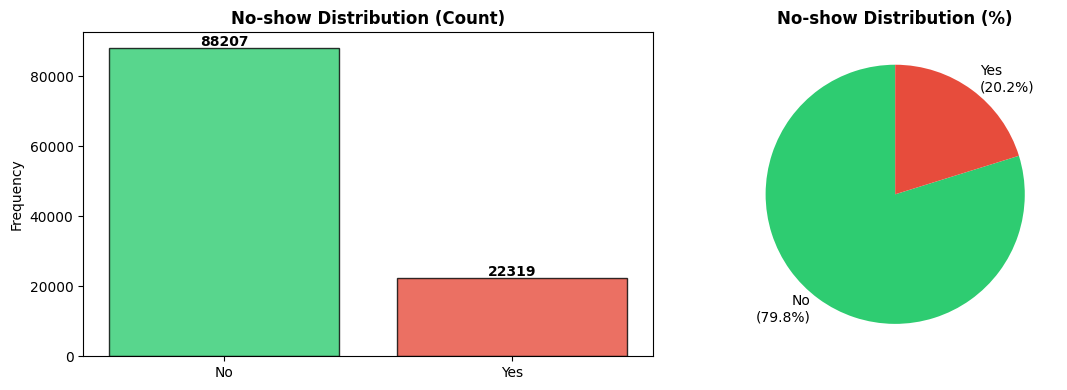


Show: 88,207 (79.81%)
No-show: 22,319 (20.19%)
 Class Imbalance Ratio: 1 : 3.95


In [31]:
### 6.1.1 Target Variable: No-show Distribution
print("\n" + "="*80)
print("6.1.1 TARGET VARIABLE: NO-SHOW DISTRIBUTION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
no_show_counts = df['No-show'].value_counts()
colors_map = {'No': '#2ecc71', 'Yes': '#e74c3c'}
colors = [colors_map[idx] for idx in no_show_counts.index]
axes[0].bar(no_show_counts.index, no_show_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('No-show Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency')
for i, v in enumerate(no_show_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
no_show_pct = df['No-show'].value_counts() / len(df) * 100
axes[1].pie(no_show_pct.values, labels=[f'{label}\n({pct:.1f}%)' for label, pct in zip(no_show_pct.index, no_show_pct.values)],
            colors=colors, autopct='', startangle=90)
axes[1].set_title('No-show Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nShow: {no_show_counts['No']:,} ({no_show_pct['No']:.2f}%)")
print(f"No-show: {no_show_counts['Yes']:,} ({no_show_pct['Yes']:.2f}%)")
print(f" Class Imbalance Ratio: 1 : {no_show_counts['No'] / no_show_counts['Yes']:.2f}")


6.1.2 DEMOGRAPHIC VARIABLES


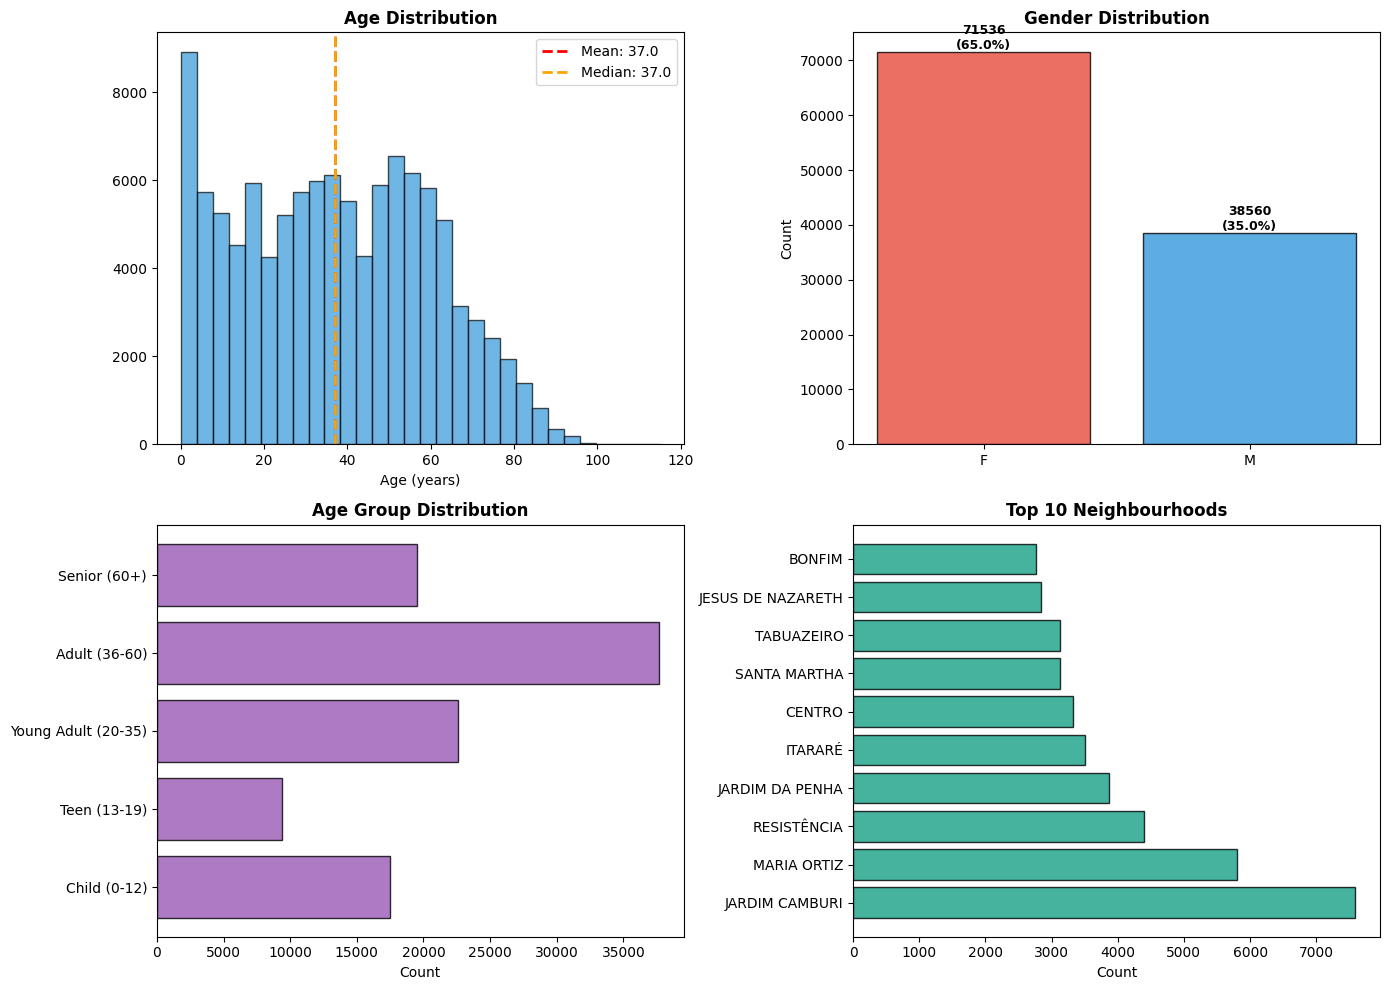


Age Statistics:
   Mean: 37.01 | Median: 37.0 | Std: 23.07

Gender Distribution:
   F: 71,536 (64.98%)
   M: 38,560 (35.02%)

Age Groups:
   Child (0-12): 17,474 (15.87%)
   Teen (13-19): 9,369 (8.51%)
   Young Adult (20-35): 22,556 (20.49%)
   Adult (36-60): 37,636 (34.18%)
   Senior (60+): 19,525 (17.73%)


In [125]:
### 6.1.2 Demographic Variables
print("\n" + "="*80)
print("6.1.2 DEMOGRAPHIC VARIABLES")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0, 0].hist(df['Age'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Mean: {df['Age'].mean():.1f}")
axes[0, 0].axvline(df['Age'].median(), color='orange', linestyle='--', linewidth=2,
                  label=f"Median: {df['Age'].median():.1f}")
axes[0, 0].legend()

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values,
               color=['#e74c3c', '#3498db'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0, 1].text(i, v + 500, f'{v}\n({v/len(df)*100:.1f}%)',
                    ha='center', fontweight='bold', fontsize=9)

# Age Group distribution
age_group_counts = df['AgeGroup'].value_counts()
age_group_order = ['Child (0-12)', 'Teen (13-19)', 'Young Adult (20-35)',
                   'Adult (36-60)', 'Senior (60+)']
age_group_counts = age_group_counts.reindex(
    [x for x in age_group_order if x in age_group_counts.index]
)
axes[1, 0].barh(age_group_counts.index, age_group_counts.values,
                color='#9b59b6', alpha=0.8, edgecolor='black')
axes[1, 0].set_title('Age Group Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# Neighbourhood (top 10)
neighbourhood_counts = df['Neighbourhood'].value_counts().head(10)
axes[1, 1].barh(neighbourhood_counts.index, neighbourhood_counts.values,
                color='#16a085', alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Top 10 Neighbourhoods', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("\nAge Statistics:")
print(f"   Mean: {df['Age'].mean():.2f} | Median: {df['Age'].median():.1f} | Std: {df['Age'].std():.2f}")

print("\nGender Distribution:")
for gender, count in gender_counts.items():
    print(f"   {gender}: {count:,} ({count/len(df)*100:.2f}%)")

print("\nAge Groups:")
for age_group, count in age_group_counts.items():
    print(f"   {age_group}: {count:,} ({count/len(df)*100:.2f}%)")



6.1.3 HEALTH CONDITION PREVALENCE


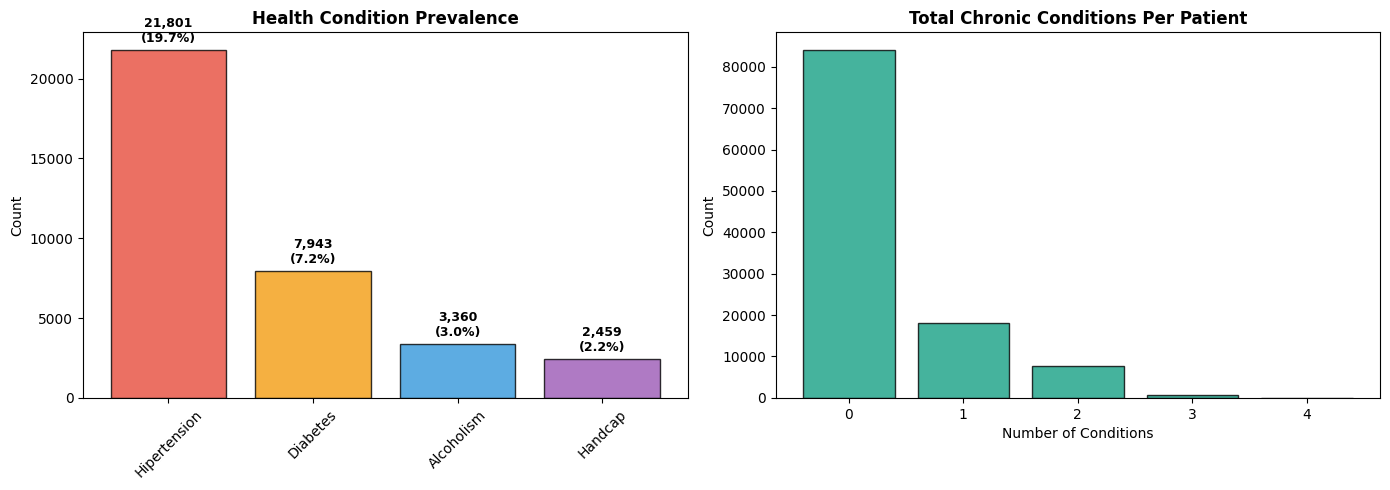


 Individual Health Conditions:
   Hipertension: 21,801 (19.72%)
   Diabetes: 7,943 (7.19%)
   Alcoholism: 3,360 (3.04%)
   Handcap: 2,459 (2.22%)

 Comorbidity Statistics:
   No conditions: 84,114 (76.10%)
   Single condition: 18,123 (16.40%)
   Multiple conditions: 8,289 (7.50%)
   Has chronic condition: 26,412 (23.90%)


In [32]:
### 6.1.3 Health Condition Prevalence
print("\n" + "="*80)
print("6.1.3 HEALTH CONDITION PREVALENCE")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Health conditions
conditions = ['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']
condition_counts = {cond: df[cond].sum() for cond in conditions}
colors_health = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']

axes[0].bar(condition_counts.keys(), condition_counts.values(), color=colors_health, alpha=0.8, edgecolor='black')
axes[0].set_title('Health Condition Prevalence', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, (cond, count) in enumerate(condition_counts.items()):
    pct = count / len(df) * 100
    axes[0].text(i, count + 500, f'{count:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=9)

# Total conditions and comorbidity
total_cond_counts = df['TotalConditions'].value_counts().sort_index()
axes[1].bar(total_cond_counts.index, total_cond_counts.values, color='#16a085', alpha=0.8, edgecolor='black')
axes[1].set_title('Total Chronic Conditions Per Patient', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Conditions')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\n Individual Health Conditions:")
for cond, count in sorted(condition_counts.items(), key=lambda x: x[1], reverse=True):
    pct = count / len(df) * 100
    print(f"   {cond}: {count:,} ({pct:.2f}%)")

print(f"\n Comorbidity Statistics:")
print(f"   No conditions: {(df['TotalConditions'] == 0).sum():,} ({(df['TotalConditions'] == 0).sum()/len(df)*100:.2f}%)")
print(f"   Single condition: {(df['TotalConditions'] == 1).sum():,} ({(df['TotalConditions'] == 1).sum()/len(df)*100:.2f}%)")
print(f"   Multiple conditions: {(df['TotalConditions'] > 1).sum():,} ({(df['TotalConditions'] > 1).sum()/len(df)*100:.2f}%)")
print(f"   Has chronic condition: {df['HasChronicCondition'].sum():,} ({df['HasChronicCondition'].sum()/len(df)*100:.2f}%)")


6.1.4 APPOINTMENT CHARACTERISTICS


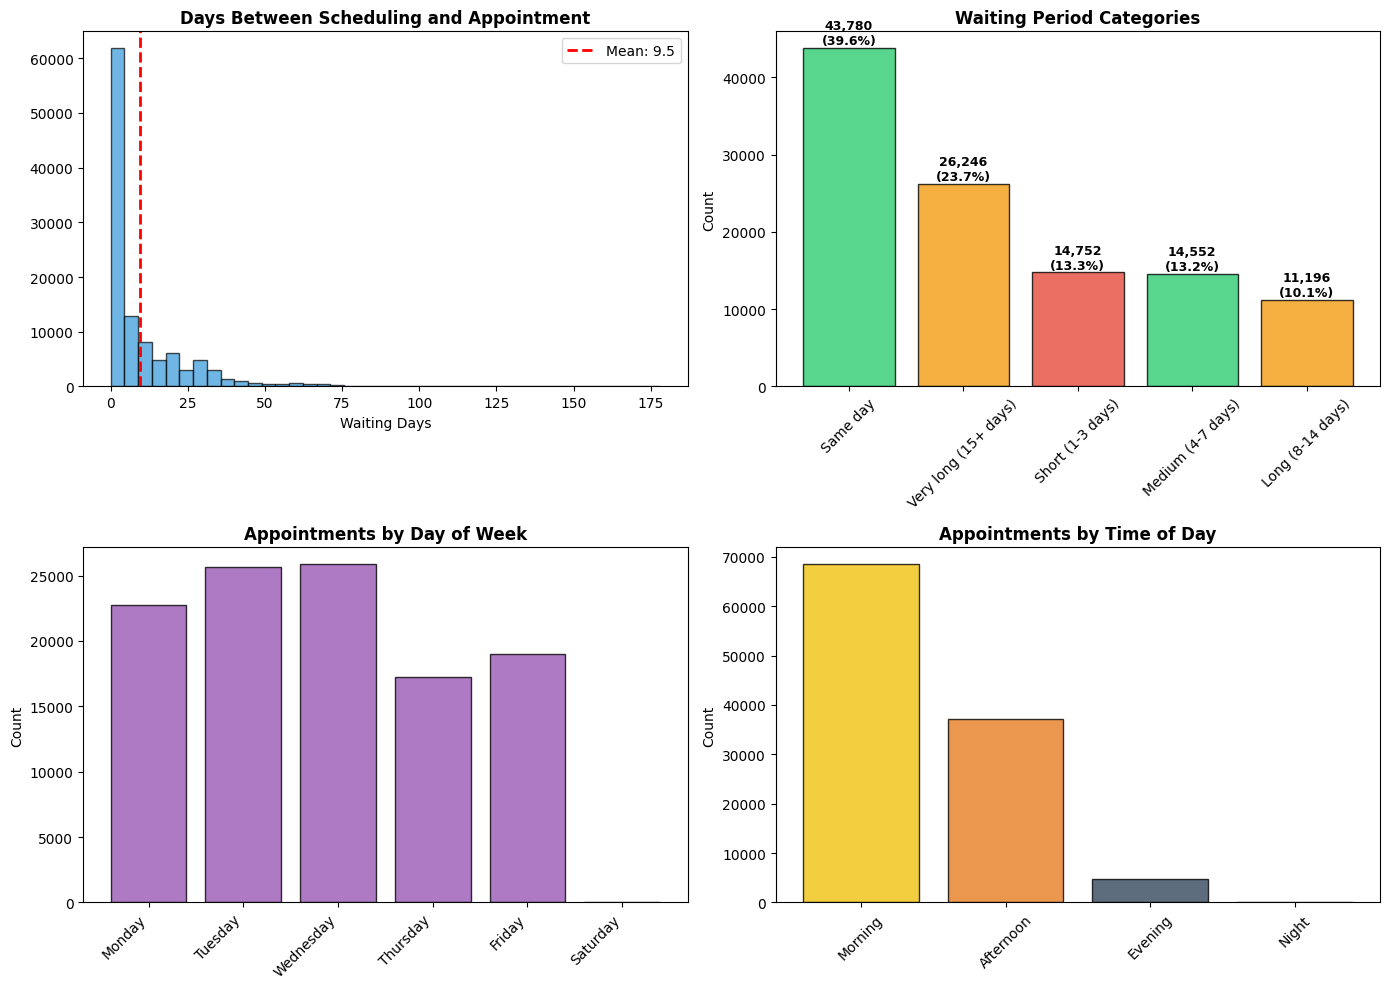


 Waiting Days Statistics:
   Mean: 9.53 | Median: 3.0 | Max: 178

  Waiting Categories:
   Same day: 43,780 (39.61%)
   Very long (15+ days): 26,246 (23.75%)
   Short (1-3 days): 14,752 (13.35%)
   Medium (4-7 days): 14,552 (13.17%)
   Long (8-14 days): 11,196 (10.13%)

 Appointment Schedule:
   Weekend appointments: 39 (0.04%)
   SMS received: 35,482 (32.10%)


In [33]:
### 6.1.4 Appointment Characteristics
print("\n" + "="*80)
print("6.1.4 APPOINTMENT CHARACTERISTICS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Waiting days
axes[0, 0].hist(df['AwaitingDays'], bins=40, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Days Between Scheduling and Appointment', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Waiting Days')
axes[0, 0].axvline(df['AwaitingDays'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['AwaitingDays'].mean():.1f}")
axes[0, 0].legend()

# Waiting category
waiting_cat = df['WaitingCategory'].value_counts()
axes[0, 1].bar(waiting_cat.index, waiting_cat.values, color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Waiting Period Categories', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, (cat, count) in enumerate(waiting_cat.items()):
    axes[0, 1].text(i, count + 500, f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=9)

# Day of week
day_of_week_counts = df['AppointmentDayOfWeek'].value_counts().sort_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1, 0].bar(range(len(day_of_week_counts)), day_of_week_counts.values, color='#9b59b6', alpha=0.8, edgecolor='black')
axes[1, 0].set_xticks(range(len(day_of_week_counts)))
axes[1, 0].set_xticklabels([day_names[i] for i in day_of_week_counts.index], rotation=45, ha='right')
axes[1, 0].set_title('Appointments by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Time of day
time_of_day_counts = df['TimeOfDay'].value_counts()
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_of_day_counts = time_of_day_counts.reindex([t for t in time_order if t in time_of_day_counts.index])
axes[1, 1].bar(time_of_day_counts.index, time_of_day_counts.values, color=['#f1c40f', '#e67e22', '#34495e', '#2c3e50'], alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Appointments by Time of Day', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n Waiting Days Statistics:")
print(f"   Mean: {df['AwaitingDays'].mean():.2f} | Median: {df['AwaitingDays'].median():.1f} | Max: {df['AwaitingDays'].max()}")
print(f"\n  Waiting Categories:")
for cat, count in waiting_cat.items():
    print(f"   {cat}: {count:,} ({count/len(df)*100:.2f}%)")
print(f"\n Appointment Schedule:")
print(f"   Weekend appointments: {df['IsWeekend'].sum():,} ({df['IsWeekend'].sum()/len(df)*100:.2f}%)")
print(f"   SMS received: {df['SMS_received'].sum():,} ({df['SMS_received'].sum()/len(df)*100:.2f}%)")


6.1.4 APPOINTMENT CHARACTERISTICS


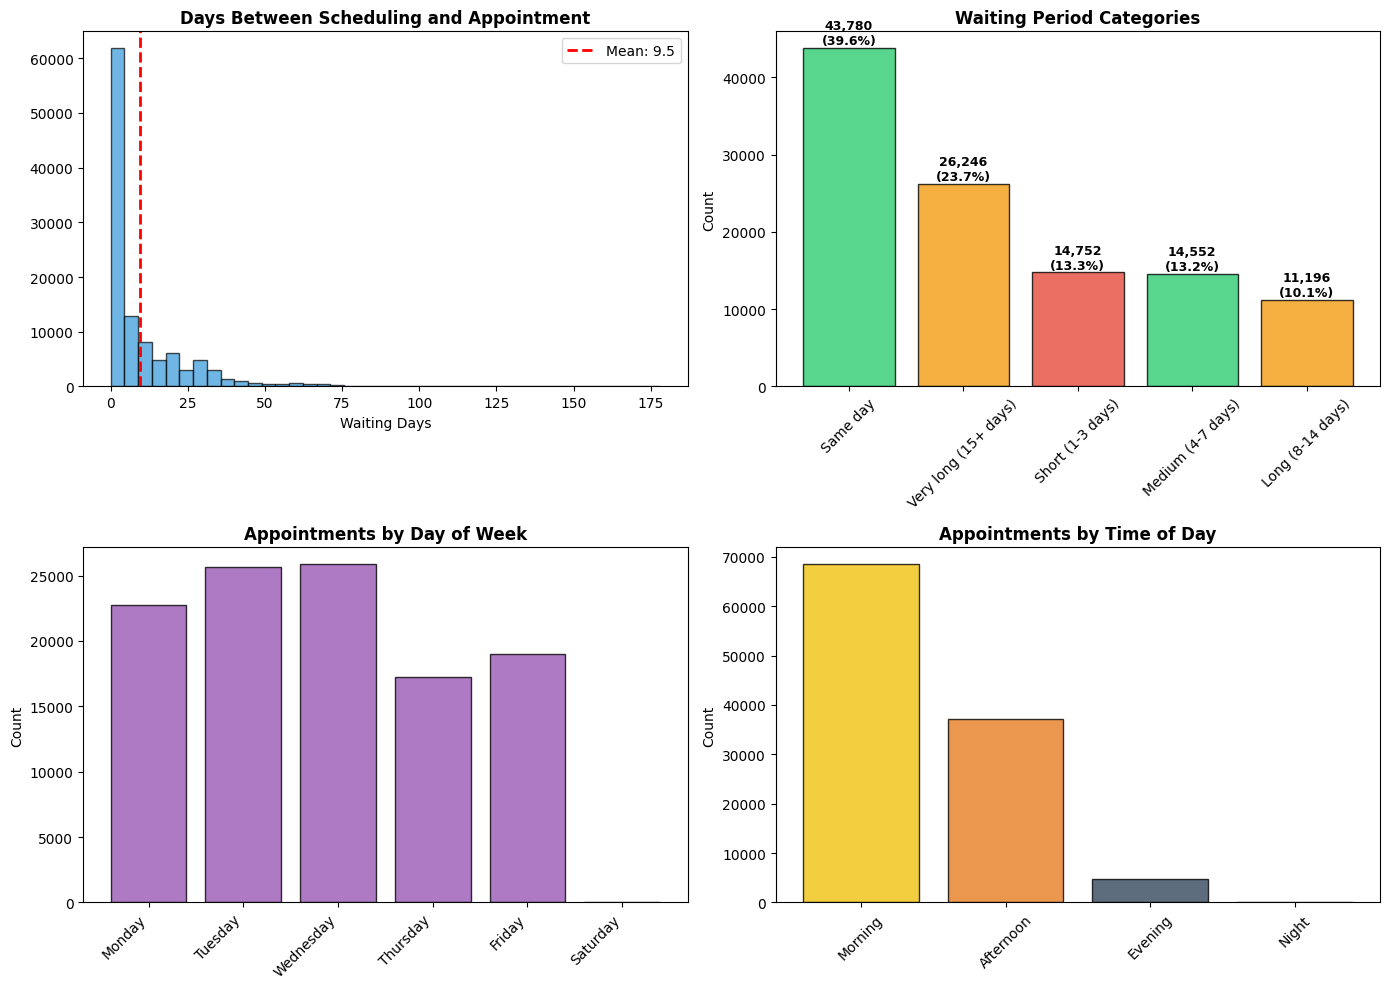


 Waiting Days Statistics:
   Mean: 9.53 | Median: 3.0 | Max: 178

  Waiting Categories:
   Same day: 43,780 (39.61%)
   Very long (15+ days): 26,246 (23.75%)
   Short (1-3 days): 14,752 (13.35%)
   Medium (4-7 days): 14,552 (13.17%)
   Long (8-14 days): 11,196 (10.13%)

 Appointment Schedule:
   Weekend appointments: 39 (0.04%)
   SMS received: 35,482 (32.10%)


In [35]:
### 6.1.4 Appointment Characteristics
print("\n" + "="*80)
print("6.1.4 APPOINTMENT CHARACTERISTICS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Waiting days
axes[0, 0].hist(df['AwaitingDays'], bins=40, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Days Between Scheduling and Appointment', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Waiting Days')
axes[0, 0].axvline(df['AwaitingDays'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['AwaitingDays'].mean():.1f}")
axes[0, 0].legend()

# Waiting category
waiting_cat = df['WaitingCategory'].value_counts()
axes[0, 1].bar(waiting_cat.index, waiting_cat.values, color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Waiting Period Categories', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, (cat, count) in enumerate(waiting_cat.items()):
    axes[0, 1].text(i, count + 500, f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=9)

# Day of week
day_of_week_counts = df['AppointmentDayOfWeek'].value_counts().sort_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1, 0].bar(range(len(day_of_week_counts)), day_of_week_counts.values, color='#9b59b6', alpha=0.8, edgecolor='black')
axes[1, 0].set_xticks(range(len(day_of_week_counts)))
axes[1, 0].set_xticklabels([day_names[i] for i in day_of_week_counts.index], rotation=45, ha='right')
axes[1, 0].set_title('Appointments by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Time of day
time_of_day_counts = df['TimeOfDay'].value_counts()
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_of_day_counts = time_of_day_counts.reindex([t for t in time_order if t in time_of_day_counts.index])
axes[1, 1].bar(time_of_day_counts.index, time_of_day_counts.values, color=['#f1c40f', '#e67e22', '#34495e', '#2c3e50'], alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Appointments by Time of Day', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n Waiting Days Statistics:")
print(f"   Mean: {df['AwaitingDays'].mean():.2f} | Median: {df['AwaitingDays'].median():.1f} | Max: {df['AwaitingDays'].max()}")
print(f"\n  Waiting Categories:")
for cat, count in waiting_cat.items():
    print(f"   {cat}: {count:,} ({count/len(df)*100:.2f}%)")
print(f"\n Appointment Schedule:")
print(f"   Weekend appointments: {df['IsWeekend'].sum():,} ({df['IsWeekend'].sum()/len(df)*100:.2f}%)")
print(f"   SMS received: {df['SMS_received'].sum():,} ({df['SMS_received'].sum()/len(df)*100:.2f}%)")

## 6.2 Bivariate Analysis


6.2.1 NO-SHOW VS DEMOGRAPHIC FACTORS


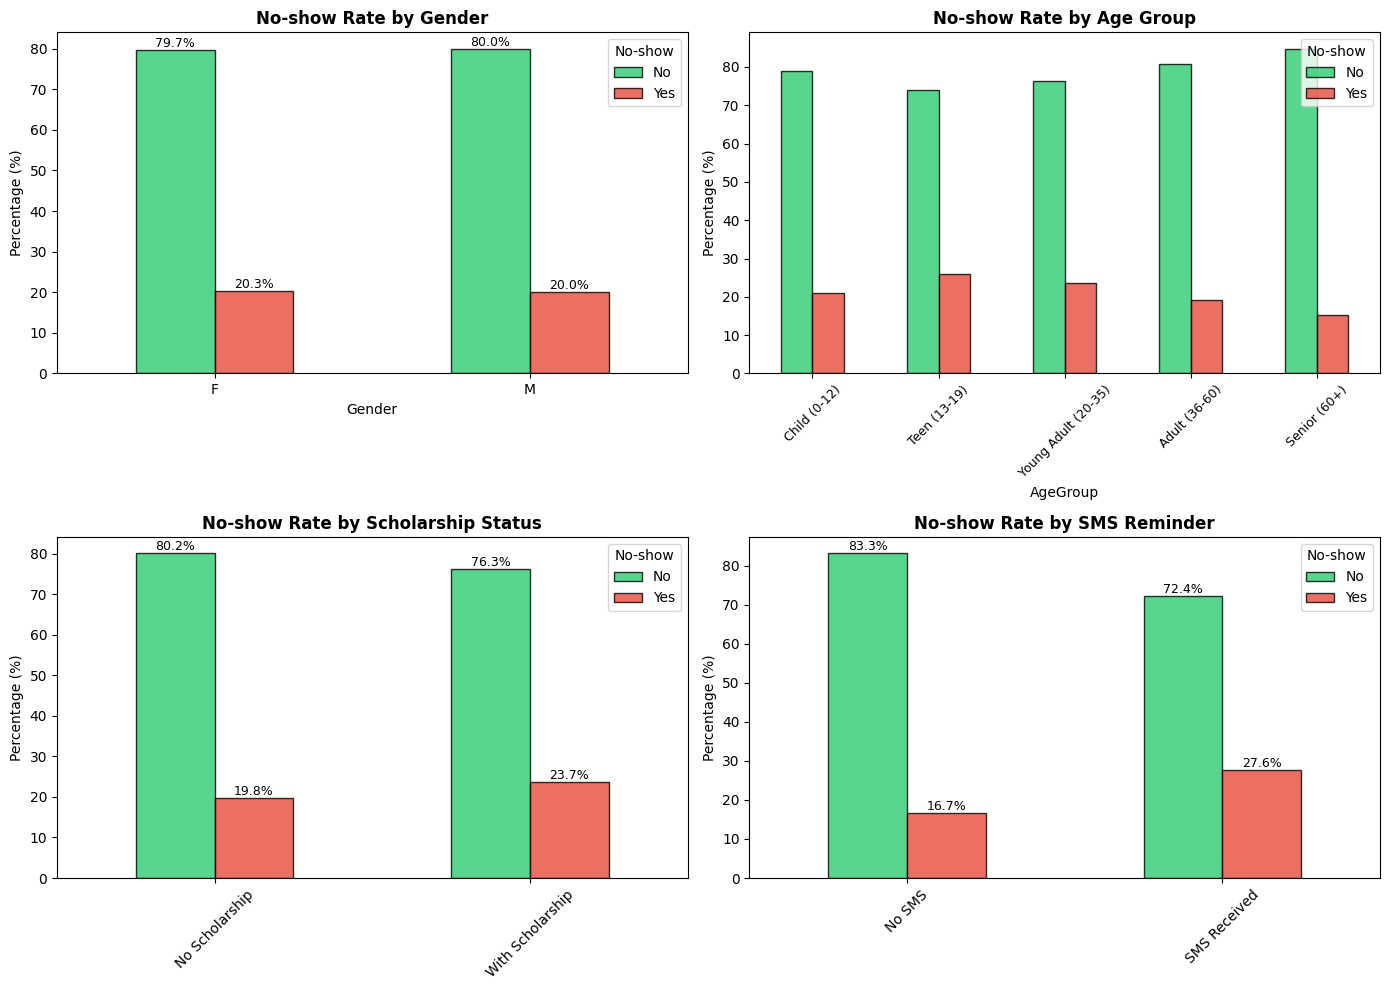


 No-show by Gender:
No-show     No    Yes
Gender               
F        79.69  20.31
M        80.03  19.97

 No-show by Age Group:
No-show                 No    Yes
AgeGroup                         
Child (0-12)         79.04  20.96
Teen (13-19)         74.04  25.96
Young Adult (20-35)  76.28  23.72
Adult (36-60)        80.90  19.10
Senior (60+)         84.80  15.20


In [36]:
### 6.2.1 No-show vs Demographic Factors
print("\n" + "="*80)
print("6.2.1 NO-SHOW VS DEMOGRAPHIC FACTORS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# No-show by gender
gender_noshow = pd.crosstab(df['Gender'], df['No-show'], normalize='index') * 100
gender_noshow.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0, 0].set_title('No-show Rate by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(title='No-show', labels=['No', 'Yes'])
axes[0, 0].tick_params(axis='x', rotation=0)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.1f%%', fontsize=9)

# No-show by age group
age_group_noshow = pd.crosstab(df['AgeGroup'], df['No-show'], normalize='index') * 100
age_group_order = ['Child (0-12)', 'Teen (13-19)', 'Young Adult (20-35)', 'Adult (36-60)', 'Senior (60+)']
age_group_noshow = age_group_noshow.reindex([x for x in age_group_order if x in age_group_noshow.index])
age_group_noshow.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('No-show Rate by Age Group', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(title='No-show', labels=['No', 'Yes'])
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=9)

# No-show by scholarship
scholarship_noshow = pd.crosstab(df['Scholarship'], df['No-show'], normalize='index') * 100
scholarship_noshow.index = ['No Scholarship', 'With Scholarship']
scholarship_noshow.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[1, 0].set_title('No-show Rate by Scholarship Status', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].legend(title='No-show', labels=['No', 'Yes'])
axes[1, 0].tick_params(axis='x', rotation=45)
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%.1f%%', fontsize=9)

# No-show by SMS received
sms_noshow = pd.crosstab(df['SMS_received'], df['No-show'], normalize='index') * 100
sms_noshow.index = ['No SMS', 'SMS Received']
sms_noshow.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[1, 1].set_title('No-show Rate by SMS Reminder', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(title='No-show', labels=['No', 'Yes'])
axes[1, 1].tick_params(axis='x', rotation=45)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n No-show by Gender:")
print(gender_noshow.round(2))
print(f"\n No-show by Age Group:")
print(age_group_noshow.round(2))


6.2.2 NO-SHOW VS HEALTH FACTORS


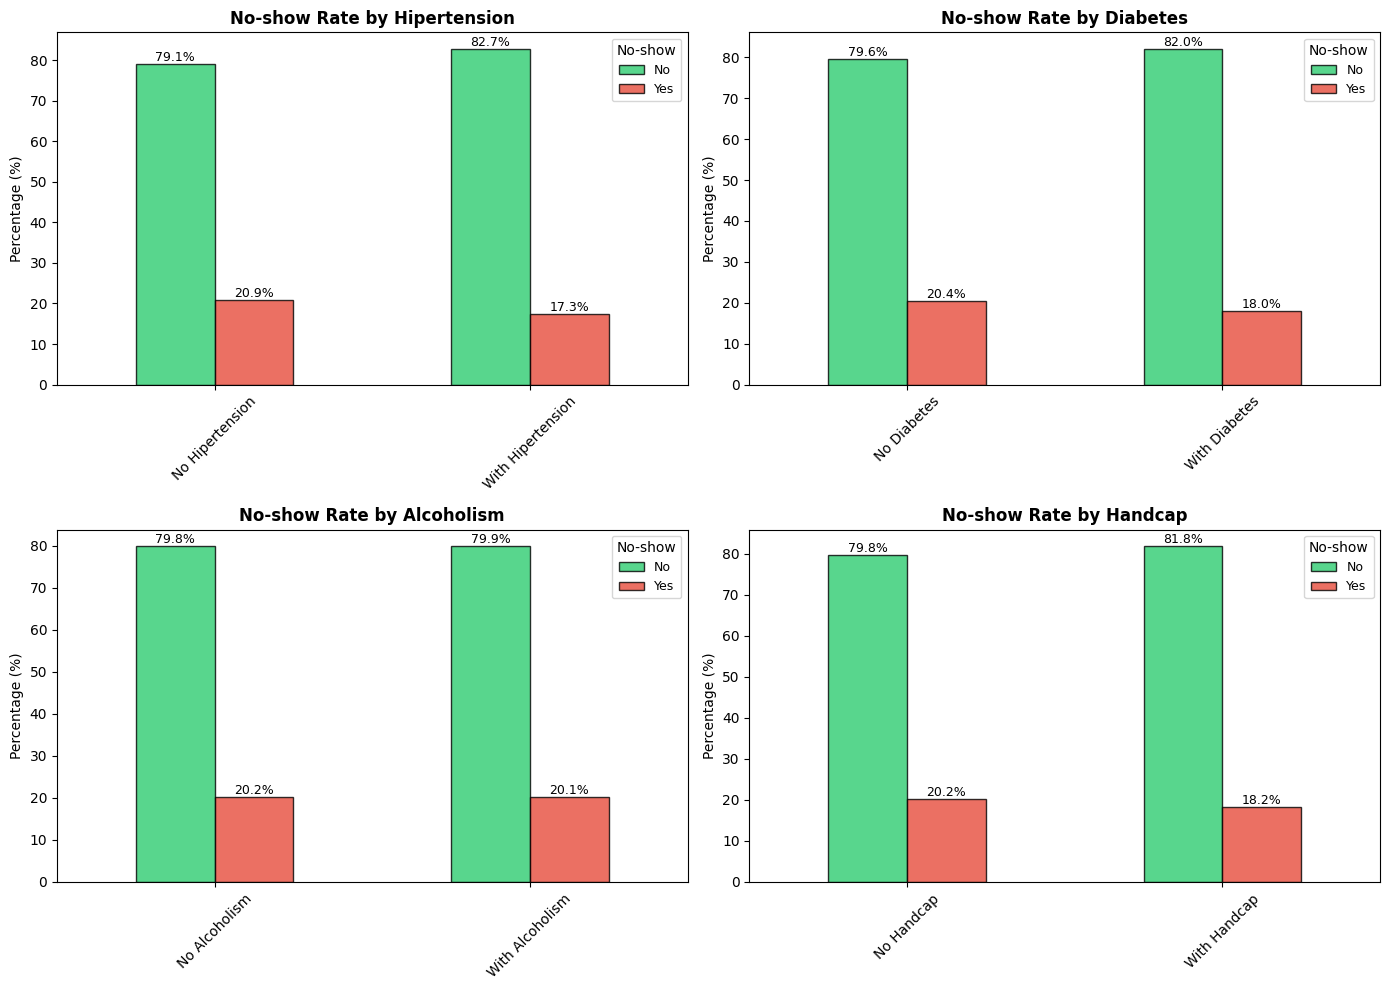


 No-show Rate by Health Condition:
   Hipertension: 17.30%
   Diabetes: 18.00%
   Alcoholism: 20.15%
   Handcap: 17.92%


In [37]:
### 6.2.2 No-show vs Health Factors
print("\n" + "="*80)
print("6.2.2 NO-SHOW VS HEALTH FACTORS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# No-show by individual conditions
conditions = ['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']
colors_condition = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']

for idx, (cond, color) in enumerate(zip(conditions, colors_condition)):
    ax = axes[idx // 2, idx % 2]
    # Convert Handcap to binary (0 or >0)
    condition_binary = (df[cond] > 0).astype(int) if cond == 'Handcap' else df[cond]
    cond_noshow = pd.crosstab(condition_binary, df['No-show'], normalize='index') * 100
    cond_noshow.index = [f'No {cond}', f'With {cond}']
    cond_noshow.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
    ax.set_title(f'No-show Rate by {cond}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.legend(title='No-show', labels=['No', 'Yes'], fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()

# Health condition impact analysis
print(f"\n No-show Rate by Health Condition:")
for cond in conditions:
    noshow_rate = (df[df[cond] == 1]['No-show'] == 'Yes').sum() / df[df[cond] == 1].shape[0] * 100 if df[cond].sum() > 0 else 0
    print(f"   {cond}: {noshow_rate:.2f}%")


6.2.3 NO-SHOW VS OPERATIONAL FACTORS


C:\Users\Admin\AppData\Local\Temp\ipykernel_11816\2739430429.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_noshow_by_bin = df.groupby(pd.cut(df['Age'], bins=age_bins))['No-show'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)


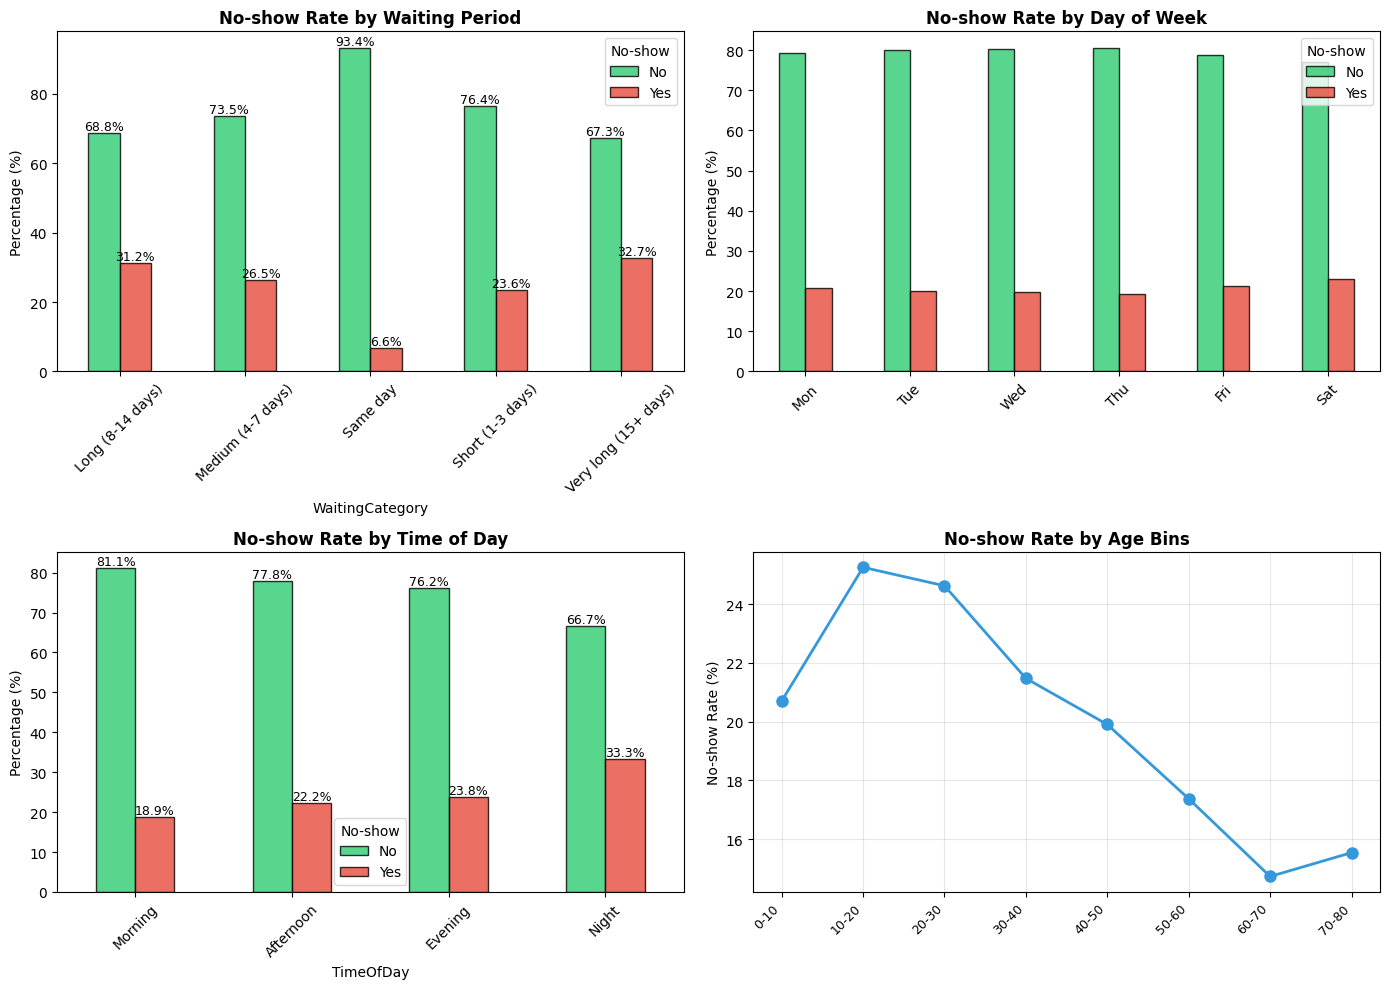


 No-show by Waiting Category:
No-show                  No    Yes
WaitingCategory                   
Long (8-14 days)      68.77  31.23
Medium (4-7 days)     73.53  26.47
Same day              93.35   6.65
Short (1-3 days)      76.43  23.57
Very long (15+ days)  67.29  32.71

  No-show by Time of Day:
No-show       No    Yes
TimeOfDay              
Morning    81.14  18.86
Afternoon  77.81  22.19
Evening    76.20  23.80
Night      66.67  33.33


In [38]:
### 6.2.3 No-show vs Operational Factors
print("\n" + "="*80)
print("6.2.3 NO-SHOW VS OPERATIONAL FACTORS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# No-show by waiting category
waiting_noshow = pd.crosstab(df['WaitingCategory'], df['No-show'], normalize='index') * 100
waiting_noshow.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0, 0].set_title('No-show Rate by Waiting Period', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(title='No-show', labels=['No', 'Yes'])
axes[0, 0].tick_params(axis='x', rotation=45)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.1f%%', fontsize=9)

# No-show by day of week
dow_noshow = pd.crosstab(df['AppointmentDayOfWeek'], df['No-show'], normalize='index') * 100
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_noshow.index = [day_names[i] for i in dow_noshow.index]
dow_noshow.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('No-show Rate by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(title='No-show', labels=['No', 'Yes'])
axes[0, 1].tick_params(axis='x', rotation=45)

# No-show by time of day
time_noshow = pd.crosstab(df['TimeOfDay'], df['No-show'], normalize='index') * 100
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_noshow = time_noshow.reindex([t for t in time_order if t in time_noshow.index])
time_noshow.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[1, 0].set_title('No-show Rate by Time of Day', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].legend(title='No-show', labels=['No', 'Yes'])
axes[1, 0].tick_params(axis='x', rotation=45)
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%.1f%%', fontsize=9)

# No-show vs Age (scatter with trend)
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_noshow_by_bin = df.groupby(pd.cut(df['Age'], bins=age_bins))['No-show'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
axes[1, 1].plot(range(len(age_noshow_by_bin)), age_noshow_by_bin.values, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[1, 1].set_xticks(range(len(age_noshow_by_bin)))
axes[1, 1].set_xticklabels([f'{int(interval.left)}-{int(interval.right)}' for interval in age_noshow_by_bin.index], rotation=45, ha='right', fontsize=9)
axes[1, 1].set_title('No-show Rate by Age Bins', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('No-show Rate (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n No-show by Waiting Category:")
print(waiting_noshow.round(2))
print(f"\n  No-show by Time of Day:")
print(time_noshow.round(2))


6.2.4 CORRELATION ANALYSIS


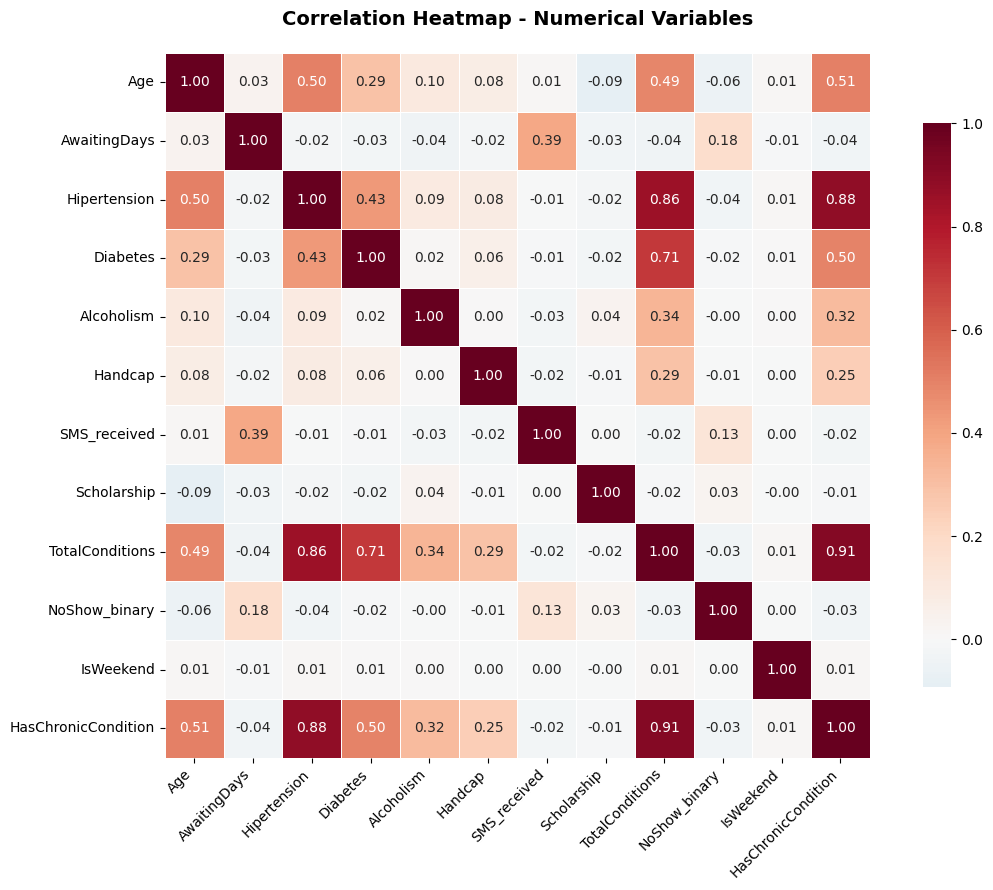


 Top Correlations with No-show (NoShow_binary):
AwaitingDays           0.180
SMS_received           0.126
Scholarship            0.029
IsWeekend              0.001
Alcoholism            -0.000
Handcap               -0.006
Diabetes              -0.015
TotalConditions       -0.031
HasChronicCondition   -0.033
Hipertension          -0.036
Age                   -0.060
Name: NoShow_binary, dtype: float64

 Association with No-show (Cramér's V):
   Gender: 0.004
   WaitingCategory: 0.283
   AgeGroup: 0.081
   TimeOfDay: 0.043


In [39]:
### 6.2.4 Correlation Heatmap
print("\n" + "="*80)
print("6.2.4 CORRELATION ANALYSIS")
print("="*80)

# Select numerical columns for correlation
numerical_cols = ['Age', 'AwaitingDays', 'Hipertension', 'Diabetes', 'Alcoholism', 
                  'Handcap', 'SMS_received', 'Scholarship', 'TotalConditions', 
                  'NoShow_binary', 'IsWeekend', 'HasChronicCondition']

corr_matrix = df[numerical_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Heatmap - Numerical Variables', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top correlations with No-show
print(f"\n Top Correlations with No-show (NoShow_binary):")
no_show_corr = corr_matrix['NoShow_binary'].sort_values(ascending=False)
print(no_show_corr[no_show_corr.index != 'NoShow_binary'].round(3))

# Cramér's V for categorical variables
print(f"\n Association with No-show (Cramér's V):")
categorical_cols = ['Gender', 'WaitingCategory', 'AgeGroup', 'TimeOfDay']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

for col in categorical_cols:
    v = cramers_v(df[col], df['No-show'])
    print(f"   {col}: {v:.3f}")

## 6.3 Statistical Tests

In [110]:
### 6.3.1 Chi-square Tests (Categorical vs Target)
from scipy.stats import chi2_contingency

print("\n" + "="*80)
print("6.3 STATISTICAL TESTS")
print("="*80)
print("\n6.3.1 CHI-SQUARE TESTS (Categorical Variables)")
print("-"*80)

categorical_vars = ['Gender', 'Scholarship', 'SMS_received', 'WaitingCategory', 'AgeGroup']

chi_square_results = []
for var in categorical_vars:
    contingency = pd.crosstab(df[var], df['No-show'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    chi_square_results.append({
        'Variable': var,
        'Chi-square': chi2,
        'p-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })
    
chi_df = pd.DataFrame(chi_square_results)
print(chi_df.to_string(index=False))
print("\n✓ p-value < 0.05 indicates significant association with No-show")


6.3 STATISTICAL TESTS

6.3.1 CHI-SQUARE TESTS (Categorical Variables)
--------------------------------------------------------------------------------
       Variable  Chi-square       p-value Significant
         Gender    1.804450  1.791754e-01          No
    Scholarship   94.321464  2.682260e-22         Yes
   SMS_received 1765.250526  0.000000e+00         Yes
WaitingCategory 8854.826988  0.000000e+00         Yes
       AgeGroup  708.830995 4.266203e-152         Yes

✓ p-value < 0.05 indicates significant association with No-show


In [89]:
from scipy.stats import spearmanr

print("\n" + "="*80)
print("6.3.2 SPEARMAN CORRELATION (Numerical Variables)")
print("-"*80)

numerical_vars = ['Age', 'AwaitingDays', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']
df['NoShow_numeric'] = (df['No-show'] == 'Yes').astype(int)

spearman_results = []
for var in numerical_vars:
    corr, p_value = spearmanr(df['NoShow_numeric'], df[var])
    spearman_results.append({
        'Variable': var,
        'Correlation': corr,
        'p-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

spearman_df = pd.DataFrame(spearman_results).sort_values('Correlation', key=abs, ascending=False)
print(spearman_df.to_string(index=False))
print("\n✓ |Correlation| > 0.1 indicates meaningful relationship")
print("✓ p-value < 0.05 indicates statistical significance")



6.3.2 SPEARMAN CORRELATION (Numerical Variables)
--------------------------------------------------------------------------------
    Variable  Correlation      p-value Significant
AwaitingDays     0.273835 0.000000e+00         Yes
         Age    -0.061394 2.051593e-92         Yes
Hipertension    -0.036462 1.027950e-33         Yes
    Diabetes    -0.015324 3.676704e-07         Yes
     Handcap    -0.007912 8.654616e-03         Yes
  Alcoholism    -0.000239 9.368160e-01          No

✓ |Correlation| > 0.1 indicates meaningful relationship
✓ p-value < 0.05 indicates statistical significance


## 7. Advanced Analysis


7.1 PRINCIPAL COMPONENT ANALYSIS (PCA)

 Explained Variance by Component:
   PC1: 27.94% | Cumulative: 27.94%
   PC2: 11.04% | Cumulative: 38.98%
   PC3: 8.21% | Cumulative: 47.19%
   PC4: 7.93% | Cumulative: 55.12%
   PC5: 7.70% | Cumulative: 62.82%


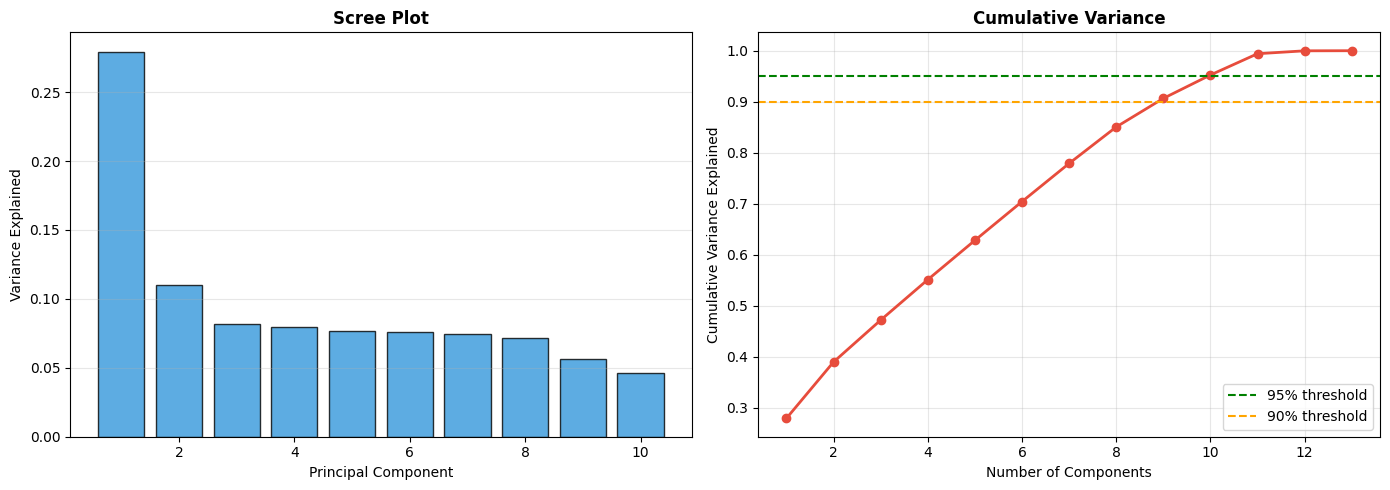


✓ Components needed for 95% variance: 10
✓ Components needed for 90% variance: 9


In [40]:
### 7.1.1 Principal Component Analysis (PCA)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\n" + "="*80)
print("7.1 PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*80)

# Prepare data
numeric_features = ['Age', 'AwaitingDays', 'Hipertension', 'Diabetes', 'Alcoholism', 
                    'Handcap', 'SMS_received', 'Scholarship', 'TotalConditions', 
                    'IsWeekend', 'HasChronicCondition', 'ScheduledHour', 'AppointmentMonth']

X = df[numeric_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

print(f"\n Explained Variance by Component:")
for i in range(min(5, len(pca.explained_variance_ratio_))):
    var_pct = pca.explained_variance_ratio_[i] * 100
    cum_var = cumsum_var[i] * 100
    print(f"   PC{i+1}: {var_pct:.2f}% | Cumulative: {cum_var:.2f}%")

# Plot variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, min(11, len(pca.explained_variance_ratio_)+1)), 
            pca.explained_variance_ratio_[:10], alpha=0.8, color='#3498db', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumsum_var)+1), cumsum_var, marker='o', linewidth=2, color='#e74c3c')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Components needed for 95% variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f"\n✓ Components needed for 95% variance: {n_components_95}")
print(f"✓ Components needed for 90% variance: {np.argmax(cumsum_var >= 0.90) + 1}")


7.2 K-MEANS CLUSTERING ANALYSIS
✓ Using 7 PCA components (77.9% variance)


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

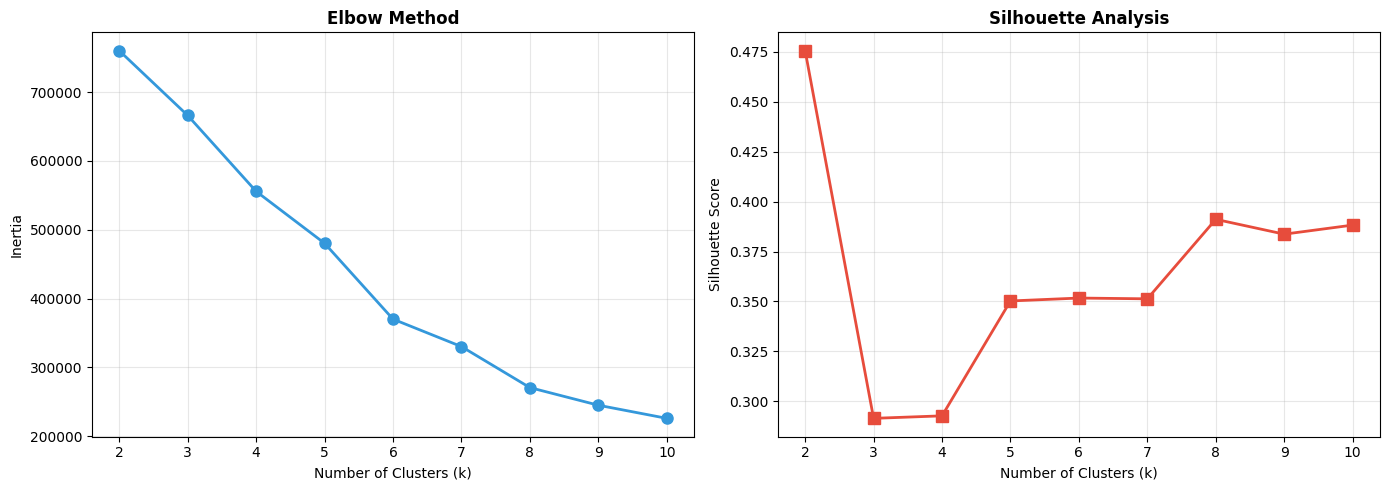


 Optimal k (by silhouette): 2

 Silhouette Scores:
   k=2: 0.4755
   k=3: 0.2915
   k=4: 0.2928
   k=5: 0.3503
   k=6: 0.3517
   k=7: 0.3513
   k=8: 0.3911
   k=9: 0.3837
   k=10: 0.3882


In [41]:
### 7.2 K-means Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("\n" + "="*80)
print("7.2 K-MEANS CLUSTERING ANALYSIS")
print("="*80)

# Use PCA-reduced data (first 7 components)
pca_reduced = PCA(n_components=7)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print(f"✓ Using 7 PCA components ({pca_reduced.explained_variance_ratio_.sum()*100:.1f}% variance)")

# Sample for faster silhouette computation (silhouette is O(n²))
sample_size = 5000
sample_idx = np.random.choice(len(X_pca_reduced), sample_size, replace=False)
X_sample = X_pca_reduced[sample_idx]

# Find optimal k using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans.fit(X_pca_reduced)
    inertias.append(kmeans.inertia_)
    # Use sample for silhouette (much faster)
    sample_labels = kmeans.predict(X_sample)
    silhouette_scores.append(silhouette_score(X_sample, sample_labels))

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='#e74c3c')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n Optimal k (by silhouette): {optimal_k}")
print(f"\n Silhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"   k={k}: {score:.4f}")


7.3 HIERARCHICAL CLUSTERING


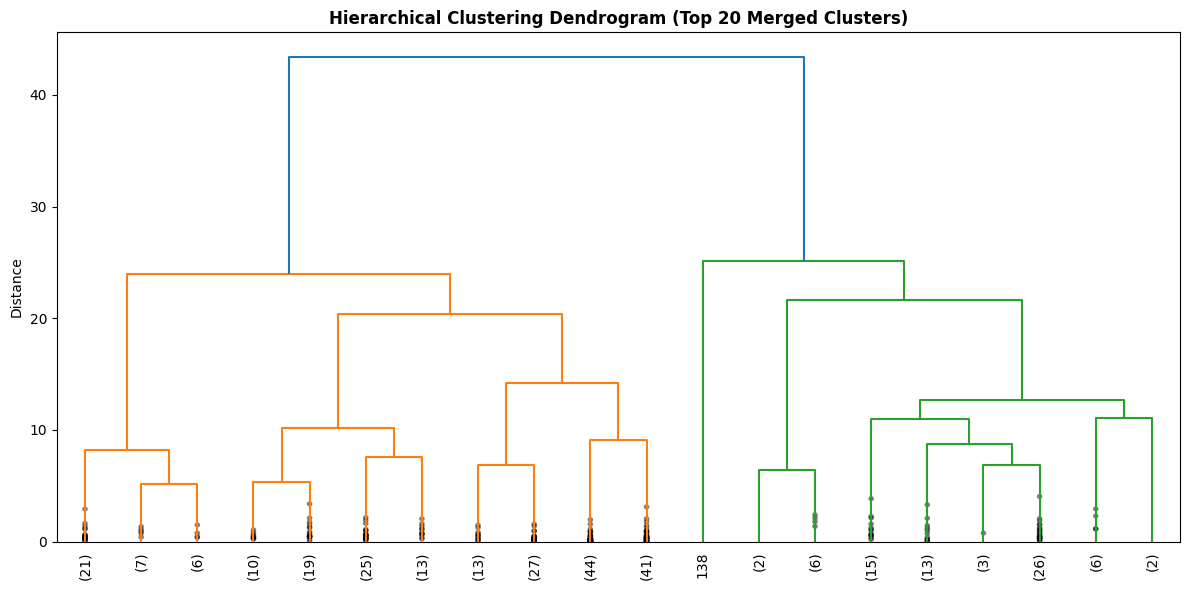


 Hierarchical clustering completed with k=2 (on 300 samples)

 Cluster Distribution:
   Cluster 0: 74 samples (24.7%)
   Cluster 1: 226 samples (75.3%)


In [42]:
### 7.3 Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

print("\n" + "="*80)
print("7.3 HIERARCHICAL CLUSTERING")
print("="*80)

# Use SMALL sample for dendrogram (linkage is O(n²) - very memory intensive)
sample_size = 300  # Reduced from 1000 to avoid memory issues
sample_idx = np.random.choice(len(X_pca_reduced), sample_size, replace=False)
X_sample_hierarchical = X_pca_reduced[sample_idx]

# Perform hierarchical clustering
linkage_matrix = linkage(X_sample_hierarchical, method='ward')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=20, 
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
ax.set_title('Hierarchical Clustering Dendrogram (Top 20 Merged Clusters)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# Agglomerative clustering with optimal k (on sample only)
agg_cluster = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels_sample = agg_cluster.fit_predict(X_sample_hierarchical)

print(f"\n Hierarchical clustering completed with k={optimal_k} (on {sample_size} samples)")
print(f"\n Cluster Distribution:")
unique, counts = np.unique(agg_labels_sample, return_counts=True)
for cluster_id, count in zip(unique, counts):
    pct = count / len(agg_labels_sample) * 100
    print(f"   Cluster {cluster_id}: {count:,} samples ({pct:.1f}%)")


7.4 GAUSSIAN MIXTURE MODELS (GMM)


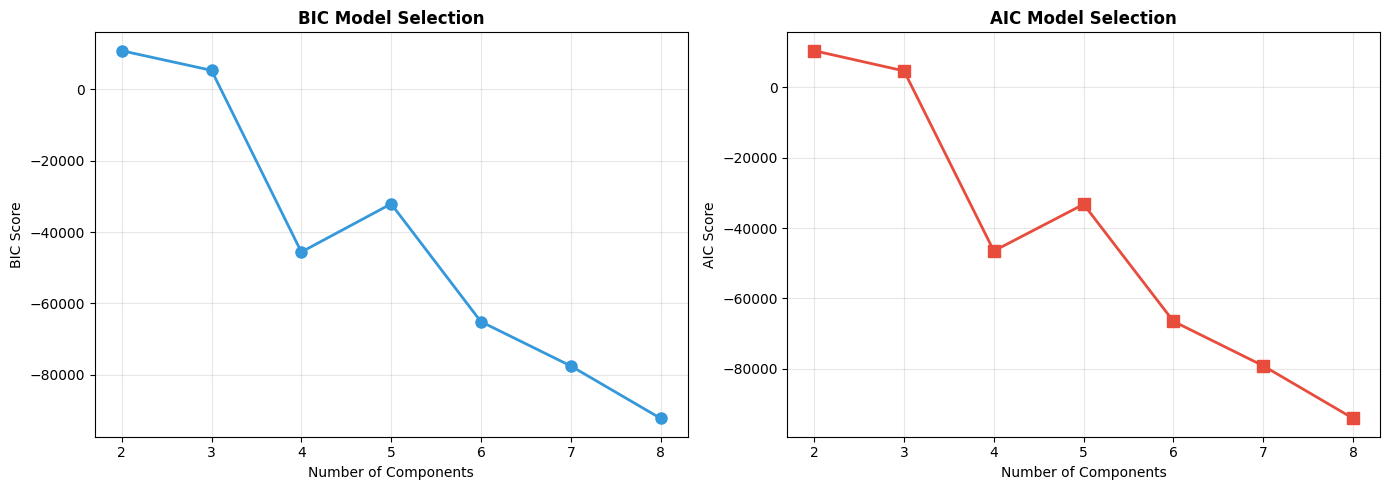


✓ Optimal components (by BIC): 8
✓ BIC score: -92232.30
✓ AIC score: -94102.74

 GMM Component Distribution (on 5000 samples):
   Component 0: 1,069 samples (21.4%)
   Component 1: 957 samples (19.1%)
   Component 2: 921 samples (18.4%)
   Component 3: 2 samples (0.0%)
   Component 4: 476 samples (9.5%)
   Component 5: 146 samples (2.9%)
   Component 6: 1,288 samples (25.8%)
   Component 7: 141 samples (2.8%)


In [43]:
### 7.4 Gaussian Mixture Models (GMM)
from sklearn.mixture import GaussianMixture

print("\n" + "="*80)
print("7.4 GAUSSIAN MIXTURE MODELS (GMM)")
print("="*80)

# Fit GMM for different components (use SMALL sample for faster computation)
sample_size = 5000  # Reduced from 10000 for memory efficiency
sample_idx = np.random.choice(len(X_pca_reduced), sample_size, replace=False)
X_gmm_sample = X_pca_reduced[sample_idx]

bic_scores = []
aic_scores = []
n_components_range = range(2, 9)  # Reduced from 11 to 9 (faster testing)

for n_comp in n_components_range:
    gmm = GaussianMixture(n_components=n_comp, random_state=42, n_init=2)  # Reduced from 3
    gmm.fit(X_gmm_sample)
    bic_scores.append(gmm.bic(X_gmm_sample))
    aic_scores.append(gmm.aic(X_gmm_sample))

# Plot model selection criteria
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_components_range, bic_scores, marker='o', linewidth=2, 
             markersize=8, color='#3498db', label='BIC')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('BIC Score')
axes[0].set_title('BIC Model Selection', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_components_range, aic_scores, marker='s', linewidth=2, 
             markersize=8, color='#e74c3c', label='AIC')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('AIC Score')
axes[1].set_title('AIC Model Selection', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optimal components
optimal_gmm = np.argmin(bic_scores) + 2
gmm_final = GaussianMixture(n_components=optimal_gmm, random_state=42, n_init=2)  # Reduced init from 10
gmm_labels_sample = gmm_final.fit_predict(X_gmm_sample)

print(f"\n✓ Optimal components (by BIC): {optimal_gmm}")
print(f"✓ BIC score: {gmm_final.bic(X_gmm_sample):.2f}")
print(f"✓ AIC score: {gmm_final.aic(X_gmm_sample):.2f}")

print(f"\n GMM Component Distribution (on {sample_size} samples):")
unique, counts = np.unique(gmm_labels_sample, return_counts=True)
for comp_id, count in zip(unique, counts):
    pct = count / len(gmm_labels_sample) * 100
    print(f"   Component {comp_id}: {count:,} samples ({pct:.1f}%)")

## 8. Predictive Modeling - XGBoost vs Random Forest Comparison

In [44]:
### 8.1 Data Preparation for Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*80)
print("8.1 DATA PREPARATION FOR MODELING")
print("="*80)

# Prepare features and target
# Drop columns not needed for modeling (including target and related columns)
features_to_drop = ['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay', 
                    'No-show', 'NoShow_numeric', 'NoShow_binary']
X_model = df.drop(columns=features_to_drop, errors='ignore')
y_model = df['NoShow_binary']

print(f"\n Dataset shape: {X_model.shape}")
print(f"   Features: {X_model.shape[1]}")
print(f"   Samples: {X_model.shape[0]:,}")

# Identify categorical columns
categorical_cols = X_model.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_model.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f" Numerical features ({len(numerical_cols)}): {numerical_cols[:5]}...")

# Encode categorical variables
X_encoded = X_model.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_model[col].astype(str))
    label_encoders[col] = le
    print(f"    Encoded '{col}' ({len(le.classes_)} classes)")

# Convert all columns to numeric (handle any remaining categorical types)
X_encoded = X_encoded.astype('float64')

print(f"\n✓ Encoded shape: {X_encoded.shape}")
print(f"✓ All columns converted to numeric")
print(f"✓ Target distribution:\n{y_model.value_counts()}")
print(f"   No-show rate: {y_model.mean()*100:.2f}%")

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_model, test_size=0.2, random_state=42, stratify=y_model
)

print(f"\n Train-test split (80-20):")
print(f"   Train: {X_train.shape[0]:,} samples")
print(f"   Test: {X_test.shape[0]:,} samples")
print(f"   Train no-show rate: {y_train.mean()*100:.2f}%")
print(f"   Test no-show rate: {y_test.mean()*100:.2f}%")


8.1 DATA PREPARATION FOR MODELING

 Dataset shape: (110526, 22)
   Features: 22
   Samples: 110,526

 Categorical features (5): ['Gender', 'Neighbourhood', 'AgeGroup', 'WaitingCategory', 'TimeOfDay']
 Numerical features (14): ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism']...
    Encoded 'Gender' (2 classes)
    Encoded 'Neighbourhood' (81 classes)
    Encoded 'AgeGroup' (6 classes)
    Encoded 'WaitingCategory' (5 classes)
    Encoded 'TimeOfDay' (4 classes)

✓ Encoded shape: (110526, 22)
✓ All columns converted to numeric
✓ Target distribution:
NoShow_binary
0    88207
1    22319
Name: count, dtype: int64
   No-show rate: 20.19%

 Train-test split (80-20):
   Train: 88,420 samples
   Test: 22,106 samples
   Train no-show rate: 20.19%
   Test no-show rate: 20.19%


In [47]:
### 8.2 XGBoost Model Training
print("\n" + "="*80)
print("8.2 XGBOOST MODEL TRAINING")
print("="*80)

# Ensure all data is numeric (no categorical types)
X_train_numeric = X_train.astype('float64')
X_test_numeric = X_test.astype('float64')

# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n Class weight ratio: {scale_pos_weight:.2f}")

# XGBoost with hyperparameters
xgb_model = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

print("\n🚀 Training XGBoost...")
xgb_model.fit(
    X_train_numeric, y_train,
    eval_set=[(X_test_numeric, y_test)],
    verbose=False
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_numeric)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_numeric)[:, 1]

# Evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"\n XGBoost Results:")
print(f"   Accuracy:  {xgb_accuracy:.4f}")
print(f"   Precision: {xgb_precision:.4f}")
print(f"   Recall:    {xgb_recall:.4f}  (Priority metric)")
print(f"   F1-Score:  {xgb_f1:.4f}")
print(f"   AUC-ROC:   {xgb_auc:.4f}")

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv_scores = cross_val_score(xgb_model, X_train_numeric, y_train, cv=skf, scoring='roc_auc')
print(f"\n 5-Fold Cross-Validation (AUC-ROC):")
print(f"   Scores: {[f'{s:.4f}' for s in xgb_cv_scores]}")
print(f"   Mean:   {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n Top 10 Important Features (XGBoost):")
for idx, row in feature_importance_xgb.head(10).iterrows():
    print(f"   {row['Feature']:20} → {row['Importance']:.4f}")


8.2 XGBOOST MODEL TRAINING

 Class weight ratio: 3.95

🚀 Training XGBoost...


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost Results:
   Accuracy:  0.6213
   Precision: 0.3202
   Recall:    0.7793  (Priority metric)
   F1-Score:  0.4539
   AUC-ROC:   0.7368


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:11] WARNING: C:\actio


 5-Fold Cross-Validation (AUC-ROC):
   Scores: ['0.7304', '0.7318', '0.7346', '0.7257', '0.7344']
   Mean:   0.7314 (+/- 0.0032)

 Top 10 Important Features (XGBoost):
   AwaitingDays         → 0.2717
   WaitingCategory      → 0.1131
   SMS_received         → 0.0465
   Age                  → 0.0440
   AgeGroup             → 0.0431
   IsSenior             → 0.0383
   AppointmentDayOfWeek → 0.0371
   HasChronicCondition  → 0.0366
   IsChild              → 0.0351
   Scholarship          → 0.0321


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:53:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [49]:
### 8.3 Random Forest Model Training
print("\n" + "="*80)
print("8.3 RANDOM FOREST MODEL TRAINING")
print("="*80)

# Random Forest with class weight handling
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\n Training Random Forest...")
rf_model.fit(X_train_numeric, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_numeric)
y_pred_proba_rf = rf_model.predict_proba(X_test_numeric)[:, 1]

# Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\n Random Forest Results:")
print(f"   Accuracy:  {rf_accuracy:.4f}")
print(f"   Precision: {rf_precision:.4f}")
print(f"   Recall:    {rf_recall:.4f}(Priority metric)")
print(f"   F1-Score:  {rf_f1:.4f}")
print(f"   AUC-ROC:   {rf_auc:.4f}")

# Cross-validation
rf_cv_scores = cross_val_score(rf_model, X_train_numeric, y_train, cv=skf, scoring='roc_auc')
print(f"\n 5-Fold Cross-Validation (AUC-ROC):")
print(f"   Scores: {[f'{s:.4f}' for s in rf_cv_scores]}")
print(f"   Mean:   {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n Top 10 Important Features (Random Forest):")
for idx, row in feature_importance_rf.head(10).iterrows():
    print(f"   {row['Feature']:20} → {row['Importance']:.4f}")


8.3 RANDOM FOREST MODEL TRAINING

 Training Random Forest...

 Random Forest Results:
   Accuracy:  0.6708
   Precision: 0.3415
   Recall:    0.6788(Priority metric)
   F1-Score:  0.4544
   AUC-ROC:   0.7359

 5-Fold Cross-Validation (AUC-ROC):
   Scores: ['0.7283', '0.7314', '0.7324', '0.7248', '0.7296']
   Mean:   0.7293 (+/- 0.0027)

 Top 10 Important Features (Random Forest):
   AwaitingDays         → 0.3135
   WaitingCategory      → 0.1384
   Neighbourhood        → 0.1203
   Age                  → 0.1196
   ScheduledHour        → 0.0723
   AppointmentDayOfWeek → 0.0534
   SMS_received         → 0.0381
   AgeGroup             → 0.0234
   AppointmentMonth     → 0.0210
   Gender               → 0.0195



8.4 MODEL COMPARISON

 Performance Comparison:
   Metric  XGBoost  Random Forest
 Accuracy 0.621279       0.670813
Precision 0.320173       0.341485
   Recall 0.779346       0.678763
 F1-Score 0.453881       0.454375
  AUC-ROC 0.736782       0.735912

 Winner on Metrics:
   XGBoost: 2/5 metrics
   Random Forest: 3/5 metrics

 RECOMMENDATION: XGBoost (AUC-ROC: 0.7368 vs 0.7359)


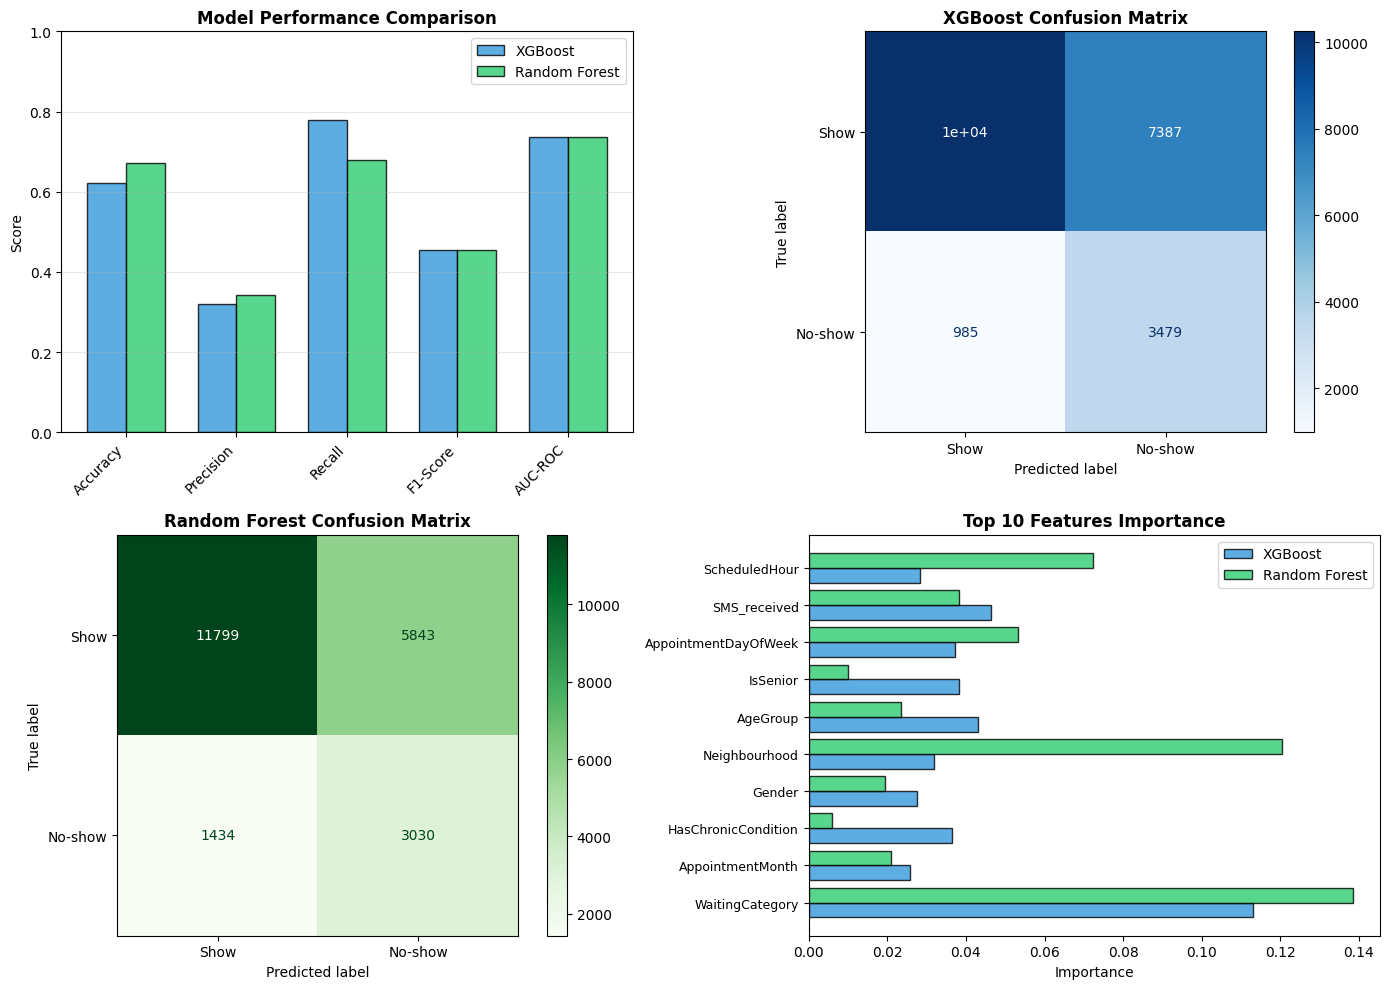


 Visualization complete!


In [51]:
### 8.4 Model Comparison & Visualization
print("\n" + "="*80)
print("8.4 MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'XGBoost': [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_auc],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc]
})

print("\n Performance Comparison:")
print(comparison_df.to_string(index=False))

# Determine winner
xgb_wins = (comparison_df['XGBoost'] > comparison_df['Random Forest']).sum()
rf_wins = (comparison_df['Random Forest'] > comparison_df['XGBoost']).sum()

print(f"\n Winner on Metrics:")
print(f"   XGBoost: {xgb_wins}/5 metrics")
print(f"   Random Forest: {rf_wins}/5 metrics")

if xgb_auc > rf_auc:
    print(f"\n RECOMMENDATION: XGBoost (AUC-ROC: {xgb_auc:.4f} vs {rf_auc:.4f})")
else:
    print(f"\n RECOMMENDATION: Random Forest (AUC-ROC: {rf_auc:.4f} vs {xgb_auc:.4f})")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Metrics comparison
metrics = comparison_df['Metric']
x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, comparison_df['XGBoost'], width, label='XGBoost', color='#3498db', alpha=0.8, edgecolor='black')
axes[0, 0].bar(x + width/2, comparison_df['Random Forest'], width, label='Random Forest', color='#2ecc71', alpha=0.8, edgecolor='black')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# Confusion matrices
from sklearn.metrics import ConfusionMatrixDisplay

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Show', 'No-show']).plot(ax=axes[0, 1], cmap='Blues')
axes[0, 1].set_title('XGBoost Confusion Matrix', fontsize=12, fontweight='bold')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Show', 'No-show']).plot(ax=axes[1, 0], cmap='Greens')
axes[1, 0].set_title('Random Forest Confusion Matrix', fontsize=12, fontweight='bold')

# Top 10 features comparison
top_features = list(set(feature_importance_xgb.head(10)['Feature'].tolist() + feature_importance_rf.head(10)['Feature'].tolist()))
top_features = top_features[:10]

xgb_imp = [feature_importance_xgb[feature_importance_xgb['Feature'] == f]['Importance'].values[0] if f in feature_importance_xgb['Feature'].values else 0 for f in top_features]
rf_imp = [feature_importance_rf[feature_importance_rf['Feature'] == f]['Importance'].values[0] if f in feature_importance_rf['Feature'].values else 0 for f in top_features]

x_feat = np.arange(len(top_features))
axes[1, 1].barh(x_feat - 0.2, xgb_imp, 0.4, label='XGBoost', color='#3498db', alpha=0.8, edgecolor='black')
axes[1, 1].barh(x_feat + 0.2, rf_imp, 0.4, label='Random Forest', color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1, 1].set_yticks(x_feat)
axes[1, 1].set_yticklabels(top_features, fontsize=9)
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top 10 Features Importance', fontsize=12, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n Visualization complete!")

## 7.4 Correspondence Analysis (CA)
Correspondence Analysis examines associations between categorical variables by creating a low-dimensional map that visualizes relationships between categories.


7.4 CORRESPONDENCE ANALYSIS (CA)

 Analysis 1: Gender vs No-show Status
--------------------------------------------------------------------------------

Contingency Table (Gender vs No-show):
No-show     No    Yes     All
Gender                       
F        57245  14594   71839
M        30962   7725   38687
All      88207  22319  110526

Chi-Square Statistic: 1.8779
Degrees of Freedom: 1

Standardized Residuals (Gender):
No-show      No     Yes
Gender                 
F       -0.3643  0.7243
M        0.4965 -0.9870


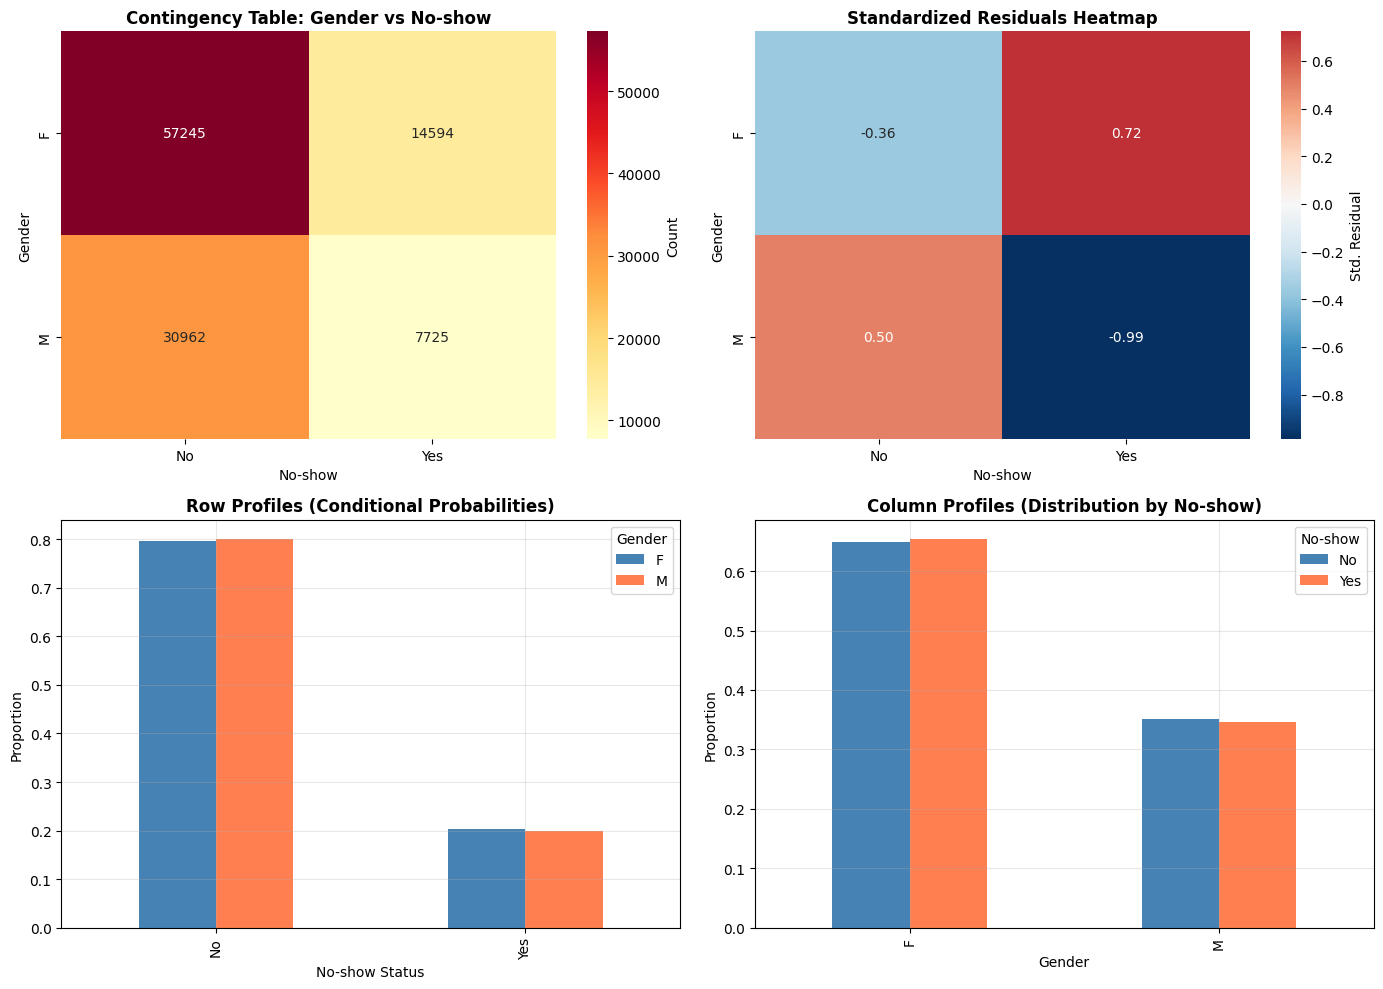


 Row Profiles:
No-show      No     Yes
Gender                 
F        0.7969  0.2031
M        0.8003  0.1997

 Column Profiles:
No-show     No     Yes
Gender                
F        0.649  0.6539
M        0.351  0.3461


In [52]:
### 7.4.1 Correspondence Analysis - Gender vs No-show

print("\n" + "="*80)
print("7.4 CORRESPONDENCE ANALYSIS (CA)")
print("="*80)

# Create contingency tables for categorical variables
print("\n Analysis 1: Gender vs No-show Status")
print("-" * 80)

gender_noshow_ct = pd.crosstab(df['Gender'], df['No-show'], margins=True)
print("\nContingency Table (Gender vs No-show):")
print(gender_noshow_ct)

# Manual correspondence analysis using SVD
from scipy.linalg import svd as scipy_svd

# Remove margins row/col for SVD
gender_noshow_ct_data = pd.crosstab(df['Gender'], df['No-show'])

# Calculate row and column totals
row_totals = gender_noshow_ct_data.sum(axis=1)
col_totals = gender_noshow_ct_data.sum(axis=0)
grand_total = gender_noshow_ct_data.sum().sum()

# Normalize by grand total
P = gender_noshow_ct_data / grand_total

# Calculate chi-square statistic
chi_sq_gender = ((gender_noshow_ct_data - (row_totals.values[:, np.newaxis] * col_totals.values / grand_total))**2 / 
                 (row_totals.values[:, np.newaxis] * col_totals.values / grand_total)).sum().sum()

print(f"\nChi-Square Statistic: {chi_sq_gender:.4f}")
print(f"Degrees of Freedom: {(len(gender_noshow_ct_data)-1) * (len(gender_noshow_ct_data.columns)-1)}")

# Standardized residuals
std_residuals_g = (gender_noshow_ct_data - (row_totals.values[:, np.newaxis] * col_totals.values / grand_total)) / np.sqrt(row_totals.values[:, np.newaxis] * col_totals.values / grand_total)
print(f"\nStandardized Residuals (Gender):")
print(std_residuals_g.round(4))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Contingency heatmap
sns.heatmap(gender_noshow_ct_data, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_title('Contingency Table: Gender vs No-show', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Gender')
axes[0, 0].set_xlabel('No-show')

# 2. Standardized residuals heatmap
sns.heatmap(std_residuals_g, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0, 1], cbar_kws={'label': 'Std. Residual'})
axes[0, 1].set_title('Standardized Residuals Heatmap', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Gender')
axes[0, 1].set_xlabel('No-show')

# 3. Row profiles (proportions by row)
row_profiles = gender_noshow_ct_data.div(row_totals, axis=0)
row_profiles.T.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'coral'])
axes[1, 0].set_title('Row Profiles (Conditional Probabilities)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].set_xlabel('No-show Status')
axes[1, 0].legend(title='Gender', loc='upper right')
axes[1, 0].grid(alpha=0.3)

# 4. Column profiles
col_profiles = gender_noshow_ct_data.div(col_totals, axis=1)
col_profiles.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'coral'])
axes[1, 1].set_title('Column Profiles (Distribution by No-show)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(title='No-show', loc='upper right')

plt.tight_layout()
plt.savefig('correspondence_analysis_gender.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Row Profiles:")
print(row_profiles.round(4))
print("\n Column Profiles:")
print(col_profiles.round(4))


7.4.2 CA: AGE GROUP VS NO-SHOW

Contingency Table (AgeGroup vs No-show):
No-show                 No    Yes     All
AgeGroup                                 
Child (0-12)         13829   3668   17497
Teen (13-19)          6941   2434    9375
Young Adult (20-35)  17233   5359   22592
Adult (36-60)        30548   7213   37761
Senior (60+)         16752   3003   19755
All                  85303  21677  106980

Chi-Square Statistic: 705.7922

Standardized Residuals (AgeGroup):
No-show                  No      Yes
AgeGroup                            
Child (0-12)        -1.0383   2.0597
Teen (13-19)        -6.1806  12.2606
Young Adult (20-35) -5.8209  11.5470
Adult (36-60)        2.5264  -5.0117
Senior (60+)         7.9668 -15.8039


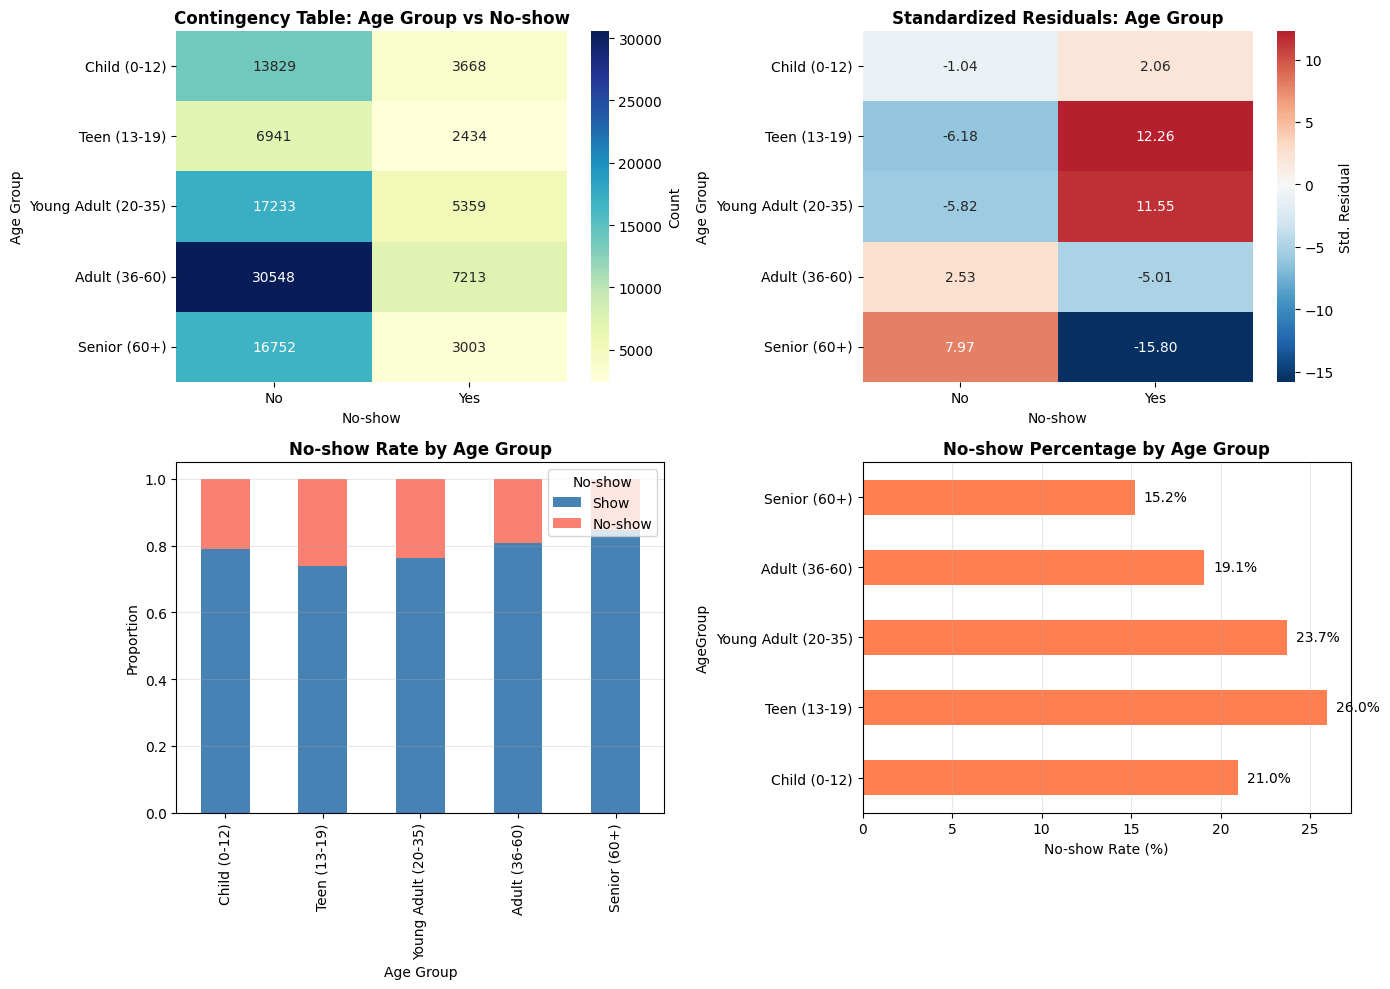


  No-show Rate by Age Group:
AgeGroup
Child (0-12)           20.96
Teen (13-19)           25.96
Young Adult (20-35)    23.72
Adult (36-60)          19.10
Senior (60+)           15.20
Name: Yes, dtype: float64


In [53]:
### 7.4.2 Correspondence Analysis - Age Group vs No-show

print("\n" + "="*80)
print("7.4.2 CA: AGE GROUP VS NO-SHOW")
print("="*80)

age_noshow_ct = pd.crosstab(df['AgeGroup'], df['No-show'], margins=True)
print("\nContingency Table (AgeGroup vs No-show):")
print(age_noshow_ct)

# CA for age group
age_noshow_ct_data = pd.crosstab(df['AgeGroup'], df['No-show'])

row_totals_a = age_noshow_ct_data.sum(axis=1)
col_totals_a = age_noshow_ct_data.sum(axis=0)
grand_total_a = age_noshow_ct_data.sum().sum()

# Chi-square
chi_sq_age = ((age_noshow_ct_data - (row_totals_a.values[:, np.newaxis] * col_totals_a.values / grand_total_a))**2 / 
              (row_totals_a.values[:, np.newaxis] * col_totals_a.values / grand_total_a)).sum().sum()

print(f"\nChi-Square Statistic: {chi_sq_age:.4f}")

# Standardized residuals
std_residuals_a = (age_noshow_ct_data - (row_totals_a.values[:, np.newaxis] * col_totals_a.values / grand_total_a)) / np.sqrt(row_totals_a.values[:, np.newaxis] * col_totals_a.values / grand_total_a)

print(f"\nStandardized Residuals (AgeGroup):")
print(std_residuals_a.round(4))

# Row and column profiles
row_profiles_a = age_noshow_ct_data.div(row_totals_a, axis=0)
col_profiles_a = age_noshow_ct_data.div(col_totals_a, axis=1)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Contingency heatmap
sns.heatmap(age_noshow_ct_data, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_title('Contingency Table: Age Group vs No-show', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Age Group')
axes[0, 0].set_xlabel('No-show')

# 2. Standardized residuals
sns.heatmap(std_residuals_a, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0, 1], cbar_kws={'label': 'Std. Residual'})
axes[0, 1].set_title('Standardized Residuals: Age Group', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Age Group')
axes[0, 1].set_xlabel('No-show')

# 3. Row profiles stacked bar
row_profiles_a.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['steelblue', 'salmon'])
axes[1, 0].set_title('No-show Rate by Age Group', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].set_xlabel('Age Group')
axes[1, 0].legend(title='No-show', labels=['Show', 'No-show'], loc='upper right')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. No-show distribution
no_show_by_age = row_profiles_a.iloc[:, 1] * 100  # % no-show
no_show_by_age.plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('No-show Percentage by Age Group', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('No-show Rate (%)')
axes[1, 1].grid(alpha=0.3, axis='x')

for i, v in enumerate(no_show_by_age.values):
    axes[1, 1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('correspondence_analysis_agegroup.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n  No-show Rate by Age Group:")
print((row_profiles_a.iloc[:, 1] * 100).round(2))

# 8. QUANTITATIVE VARIABLE ANALYSIS
In this section, we analyze the quantitative variables: `Age`, `AwaitingDays`, and `TotalConditions`.

In [ ]:
# Ensure df is loaded (if running this section independently)
if 'df' not in locals():
    import pandas as pd
    try:
        df = pd.read_csv("medical_appointments_with_features.csv")
        print("Dataset loaded.")
    except:
        print("Warning: Dataset not found. Please run previous cells.")

# Define quantitative columns
quant_cols = ['Age', 'AwaitingDays', 'TotalConditions']

# Summary Statistics
print("="*50)
print("SUMMARY STATISTICS FOR QUANTITATIVE VARIABLES")
print("="*50)
print(df[quant_cols].describe().round(2))

SUMMARY STATISTICS FOR QUANTITATIVE VARIABLES
             Age  AwaitingDays  TotalConditions
count  110526.00     110526.00        110526.00
mean       37.09          9.53             0.32
std        23.11         15.03             0.63
min         0.00          0.00             0.00
25%        18.00          0.00             0.00
50%        37.00          3.00             0.00
75%        55.00         14.00             0.00
max       115.00        178.00             4.00
